# Hybrid Ensemble: Telemanom + IForest + XGBoost

## Architecture Overview

This notebook implements a state-of-the-art hybrid anomaly detection ensemble:

### Three-Stage Pipeline:

**Stage 1: Base Anomaly Detectors**
- **Telemanom** → Temporal anomaly signal (drift, trajectory deviation, forecast error)
- **IsolationForest** → Multivariate structural anomaly signal (outlier detection)

**Stage 2: Feature Engineering + XGBoost Fusion**
- Combine base detector scores
- Add rolling statistics, deltas, slopes
- Channel cross-correlations
- XGBoost learns optimal decision boundaries

**Stage 3: Post-Processing**
- Event merging (gap closing)
- Minimum length filtering
- Remove isolated flickers

### Why This Works:
1. **Telemanom** fixes temporal blindness → catches drifts and sequence anomalies
2. **IForest** provides multivariate geometry → catches structural outliers
3. **XGBoost** automates fusion → no manual threshold tuning

---

We'll implement each detector **one by one**, testing and visualizing results as we go.

## Step 0: Setup and Data Loading

In [1]:
import os
import sys

# Determinism: pin BLAS/OpenMP thread pools to 1 BEFORE numpy/sklearn/xgboost
# are imported (env vars only take effect if set prior to the first import
# that initializes the thread pools). Multithreaded float summation is
# nondeterministic run-to-run even with a fixed random_state.
for _env in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
             'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_env] = '1'

import gc

# Single seed constant used everywhere something stochastic happens
# (IsolationForest, XGBoost). The block-based chronological split itself
# uses no RNG (pure index arithmetic).
SEED = 42
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings


In [2]:
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

print("✓ Core libraries imported")
print(f"  NumPy version: {np.__version__}")
print(f"  Pandas version: {pd.__version__}")

✓ Core libraries imported
  NumPy version: 2.1.3
  Pandas version: 2.2.3


In [3]:
# Load test data from parquet file (memory-safe: column projection + float32 downcast)
data_path = Path('.data/test.parquet')

TEST_FEATURE_COLS = [f'channel_{i}' for i in range(41, 47)]  # channel_41 to channel_46

if not data_path.exists():
    print(f" Error: Data file not found at {data_path}")
    print("Please ensure the data file exists.")
else:
    test_table = pq.read_table(data_path, columns=['id'] + TEST_FEATURE_COLS, use_threads=False)
    df_test = test_table.to_pandas()
    del test_table
    gc.collect()

    for col in TEST_FEATURE_COLS:
        df_test[col] = df_test[col].astype(np.float32)
    df_test['id'] = df_test['id'].astype(np.int64)

    print(f"[OK] Data loaded successfully from parquet (column-projected: id + 6 channels)")
    print(f"  Shape: {df_test.shape}")
    print(f"  Columns: {df_test.columns.tolist()}")
    print(f"\nFirst few rows:")
    display(df_test.head())


[OK] Data loaded successfully from parquet (column-projected: id + 6 channels)
  Shape: (521280, 7)
  Columns: ['id', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

First few rows:


,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46
0,14728321,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
1,14728322,0.807868,0.794377,0.764778,0.797604,0.820247,0.764451
2,14728323,0.808654,0.792770,0.763195,0.795242,0.821094,0.753472
3,14728324,0.806299,0.791966,0.765569,0.796030,0.820247,0.763607
4,14728325,0.809439,0.799195,0.763195,0.796816,0.821941,0.760229


In [4]:
# Load train data: memory-safe block-sampled read from parquet
#
# Problem 3 fix: training on only the first 521,280 rows (~3.5% of the
# mission) was both too small and statistically unrepresentative. We instead
# sample 10 contiguous blocks of 150,000 rows spread evenly across the full
# 14,728,321-row mission timeline (1,500,000 rows total, ~10.2%).
#
# Memory-safety hard constraint: never materialize the full 14.7M x 87 file.
# We use pyarrow column projection (id + 6 channels + is_anomaly only) and
# read only the parquet row groups that overlap each sampled block, so at
# most ~2 row groups (~75MB) are ever in memory at once during loading.

data_path_train = Path('.data/train.parquet')
TRAIN_FEATURE_COLS = [f'channel_{i}' for i in range(41, 47)]
BLOCK_SIZE = 150_000
N_BLOCKS = 10

if not data_path_train.exists():
    print(f" Error: Data file not found at {data_path_train}")
    print("Please ensure the data file exists.")
else:
    pf = pq.ParquetFile(data_path_train)
    total_rows = pf.metadata.num_rows

    # Evenly-spaced, non-overlapping block start positions spanning the full timeline
    max_start = total_rows - BLOCK_SIZE
    block_starts = [int(round(k * max_start / (N_BLOCKS - 1))) for k in range(N_BLOCKS)]

    # Map row groups to their global row offsets
    row_group_offsets = []
    offset = 0
    for rg in range(pf.num_row_groups):
        n = pf.metadata.row_group(rg).num_rows
        row_group_offsets.append((offset, offset + n))
        offset += n

    needed_cols = ['id'] + TRAIN_FEATURE_COLS + ['is_anomaly']
    block_frames = []
    for b, start in enumerate(block_starts):
        end = start + BLOCK_SIZE  # exclusive
        rg_indices = [i for i, (s, e) in enumerate(row_group_offsets) if e > start and s < end]
        table = pf.read_row_groups(rg_indices, columns=needed_cols, use_threads=False)
        rg_first_offset = row_group_offsets[rg_indices[0]][0]
        local_start = start - rg_first_offset
        block_df = table.slice(local_start, BLOCK_SIZE).to_pandas()
        assert len(block_df) == BLOCK_SIZE, f"block {b} got {len(block_df)} rows, expected {BLOCK_SIZE}"
        block_df['block'] = b
        block_frames.append(block_df)
        del table
    del pf
    gc.collect()

    df_train = pd.concat(block_frames, ignore_index=True)
    del block_frames
    gc.collect()

    for col in TRAIN_FEATURE_COLS:
        df_train[col] = df_train[col].astype(np.float32)
    df_train['id'] = df_train['id'].astype(np.int64)
    df_train['is_anomaly'] = df_train['is_anomaly'].astype(np.int32)
    df_train['block'] = df_train['block'].astype(np.int32)

    print(f"[OK] Train data loaded via block sampling (memory-safe)")
    print(f"  Full mission timeline: {total_rows:,} rows")
    print(f"  Sampled: {N_BLOCKS} blocks x {BLOCK_SIZE:,} rows = {len(df_train):,} rows "
          f"({len(df_train)/total_rows*100:.2f}% of full timeline)")
    block_first_ids = [int(df_train.loc[df_train['block'] == b, 'id'].iloc[0]) for b in range(N_BLOCKS)]
    print(f"  Block starting ids: {block_first_ids}")
    print(f"\nFirst few rows:")
    display(df_train.head())


[OK] Train data loaded via block sampling (memory-safe)
  Full mission timeline: 14,728,321 rows
  Sampled: 10 blocks x 150,000 rows = 1,500,000 rows (10.18% of full timeline)
  Block starting ids: [0, 1619813, 3239627, 4859440, 6479254, 8099067, 9718881, 11338694, 12958508, 14578321]

First few rows:


,id,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46,is_anomaly,block
0,0,0.812578,0.786344,0.771900,0.799178,0.816855,0.765296,0,0
1,1,0.812578,0.786344,0.771900,0.799178,0.816855,0.765296,0,0
2,2,0.821213,0.789557,0.770317,0.809411,0.816006,0.765296,0,0
3,3,0.819642,0.786344,0.770317,0.807050,0.816855,0.766985,0,0
4,4,0.821996,0.788753,0.770317,0.807837,0.818551,0.761073,0,0


In [5]:
# Prepare feature matrix - USING ONLY CHANNELS 41-46
# Problem 2 fix: 'id' is a non-physical row index (train/test id ranges are
# disjoint), not a telemetry feature. It is excluded from feature_cols; it is
# kept separately (train_ids) only for the chronological-split assertion.
feature_cols = [f'channel_{i}' for i in range(41, 47)]  # channel_41 to channel_46

missing_channels = [ch for ch in feature_cols if ch not in df_test.columns]
if missing_channels:
    raise ValueError(f"Missing target channels: {missing_channels}")

print(f" Using Target Channels: {feature_cols}")

# Extract channels 41-46 TEST (full Kaggle test set)
X_raw_test = df_test[feature_cols].values.astype(np.float32)
data_test = df_test[feature_cols]
n_samples, n_features = X_raw_test.shape

# Extract channels 41-46 TRAIN (10-block representative sample, 1.5M rows)
X_raw_train = df_train[feature_cols].values.astype(np.float32)
y_raw_train = df_train["is_anomaly"].values
train_ids = df_train["id"].values
train_blocks = df_train["block"].values
data_train = df_train[feature_cols]
n_samples_train, n_features_train = data_train.shape

print(f"\n Dataset Summary TEST:")
print(f"  Total samples: {n_samples:,}")
print(f"  Total features: {n_features} (channels 41-46)")
print(f"  Feature names: {feature_cols}")
print(f"\n  Data range: [{np.min(data_test):.4f}, {np.max(data_test):.4f}]")
print(f"  Missing values: {np.isnan(data_test).sum()}")

print(f"\n Dataset Summary TRAIN:")
print(f"  Total samples: {n_samples_train:,}")
print(f"  Total features: {n_features_train} (channels 41-46)")
print(f"  Feature names: {feature_cols}")
print(f"\n  Data range: [{np.min(data_train):.4f}, {np.max(data_train):.4f}]")
print(f"  Missing values: {np.isnan(data_train).sum()}")
print(f"  Anomaly rate in sample: {y_raw_train.mean()*100:.3f}%")


 Using Target Channels: ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

 Dataset Summary TEST:
  Total samples: 521,280
  Total features: 6 (channels 41-46)
  Feature names: ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

  Data range: [0.0000, 0.9686]
  Missing values: channel_41    0
channel_42    0
channel_43    0
channel_44    0
channel_45    0
channel_46    0
dtype: int64

 Dataset Summary TRAIN:
  Total samples: 1,500,000
  Total features: 6 (channels 41-46)
  Feature names: ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

  Data range: [0.0000, 0.9958]
  Missing values: channel_41    0
channel_42    0
channel_43    0
channel_44    0
channel_45    0
channel_46    0
dtype: int64
  Anomaly rate in sample: 11.144%


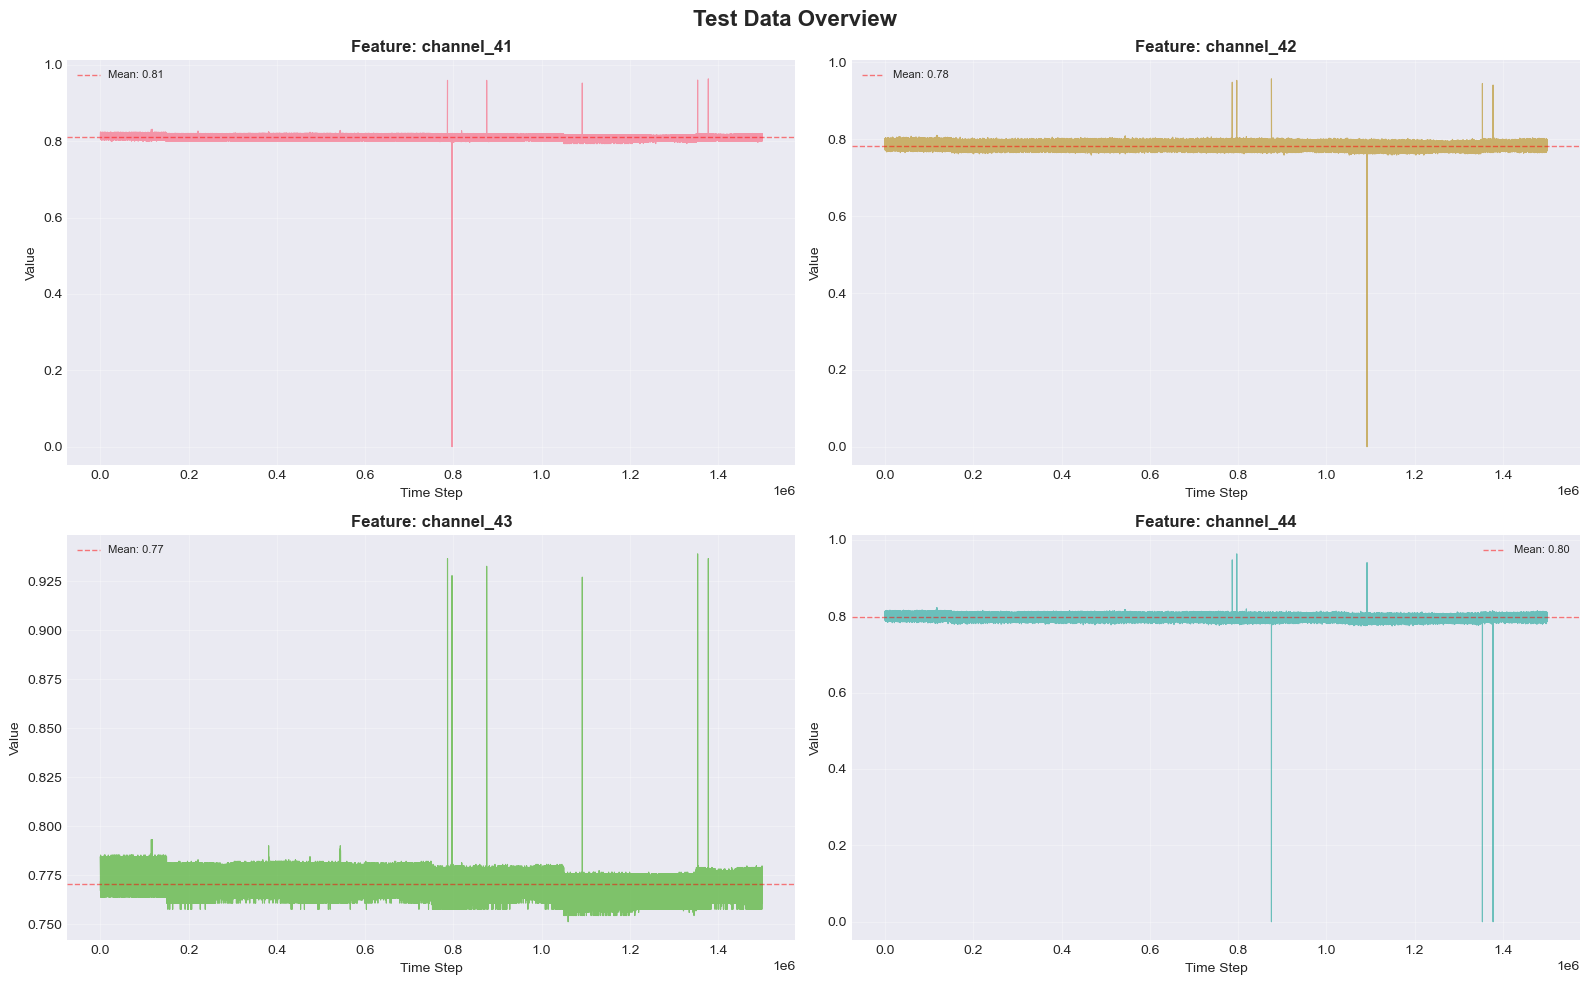


✓ Data visualization complete

Ready to implement DETECTOR 1: ISOLATION FOREST


In [6]:
# Visualize data overview TRAIN DATA
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Test Data Overview', fontsize=16, fontweight='bold')

# Plot first 4 features
for idx in range(4):
    ax = axes[idx // 2, idx % 2]
    ax.plot(X_raw_train[:, idx], alpha=0.7, linewidth=0.8, color=f'C{idx}')
    ax.set_title(f'Feature: {feature_cols[idx]}', fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(X_raw_train[:, idx])
    std_val = np.std(X_raw_train[:, idx])
    ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.5, linewidth=1, label=f'Mean: {mean_val:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Data visualization complete")
print("\n" + "="*80)
print("Ready to implement DETECTOR 1: ISOLATION FOREST")
print("="*80)

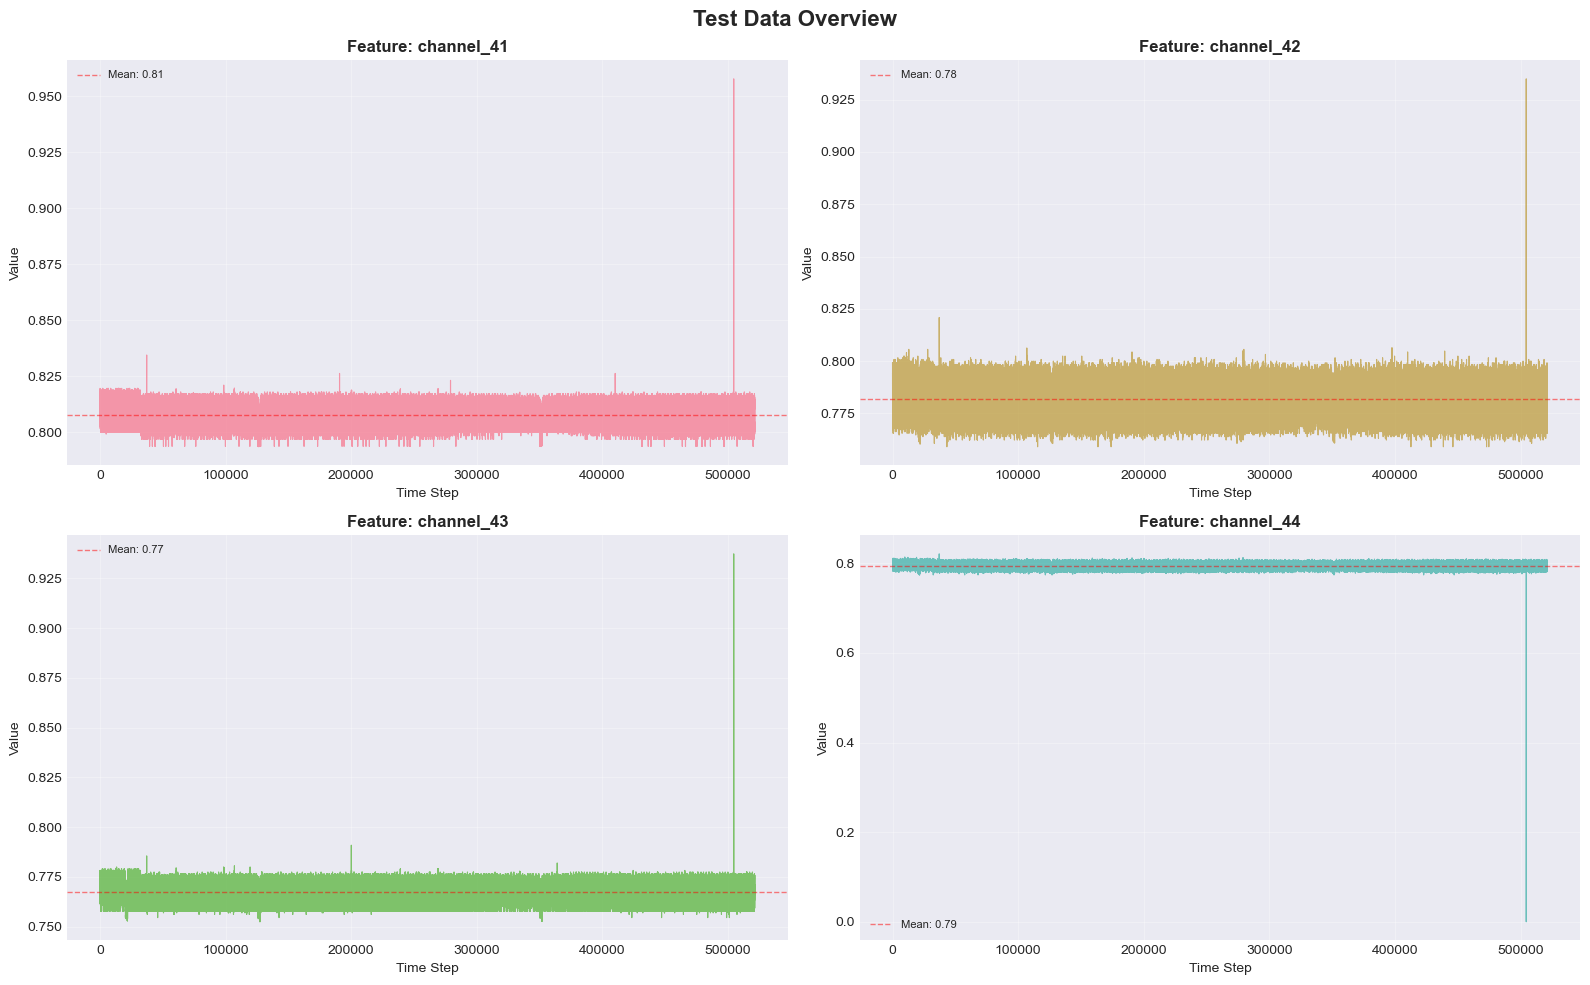


✓ Data visualization complete

Ready to implement DETECTOR 1: ISOLATION FOREST


In [7]:
# Visualize data overview TEST DATA
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Test Data Overview', fontsize=16, fontweight='bold')

# Plot first 4 features
for idx in range(4):
    ax = axes[idx // 2, idx % 2]
    ax.plot(X_raw_test[:, idx], alpha=0.7, linewidth=0.8, color=f'C{idx}')
    ax.set_title(f'Feature: {feature_cols[idx]}', fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(X_raw_test[:, idx])
    std_val = np.std(X_raw_test[:, idx])
    ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.5, linewidth=1, label=f'Mean: {mean_val:.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Data visualization complete")
print("\n" + "="*80)
print("Ready to implement DETECTOR 1: ISOLATION FOREST")
print("="*80)

In [8]:
# train_test split of the TRAIN set - CHRONOLOGICAL, NO SHUFFLING
# Problem 1 fix: the original used train_test_split(..., shuffle=True) on
# autocorrelated time-series data, leaking near-duplicate temporal neighbors
# across the split. Blocks are laid out in time order (block 0 earliest ...
# block 9 latest); the last 2 of 10 blocks (300,000 rows, 20%) are reserved
# for validation, matching the original 80/20 ratio, so every validation row
# is strictly later in time than every training row.

N_VAL_BLOCKS = 2
train_block_mask = train_blocks < (N_BLOCKS - N_VAL_BLOCKS)
val_block_mask = ~train_block_mask

X_train = X_raw_train[train_block_mask]
X_val = X_raw_train[val_block_mask]
y_train = y_raw_train[train_block_mask]
y_val = y_raw_train[val_block_mask]
ids_train = train_ids[train_block_mask]
ids_val = train_ids[val_block_mask]

assert ids_train.max() < ids_val.min(), \
    "Chronological split violated: some validation rows are earlier than some training rows"

print(f"Chronological split (no shuffle):")
print(f"  Train: {len(X_train):,} rows (blocks 0-{N_BLOCKS-N_VAL_BLOCKS-1}, "
      f"ids {ids_train.min():,}-{ids_train.max():,})")
print(f"  Val:   {len(X_val):,} rows (blocks {N_BLOCKS-N_VAL_BLOCKS}-{N_BLOCKS-1}, "
      f"ids {ids_val.min():,}-{ids_val.max():,})")
print(f"  Assertion passed: max(train id) < min(val id)")


Chronological split (no shuffle):
  Train: 1,200,000 rows (blocks 0-7, ids 0-11,488,693)
  Val:   300,000 rows (blocks 8-9, ids 12,958,508-14,728,320)
  Assertion passed: max(train id) < min(val id)


---
##  STAGE 1.1: Detector 1 - Isolation Forest

**Role:** Multivariate structural anomaly detection

**What it detects:**
- Point-wise outliers in feature space
- Multivariate geometric anomalies
- Unusual feature combinations

**How it works:**
- Randomly partitions feature space
- Anomalies are isolated with fewer partitions
- Fast and effective for high-dimensional data

In [9]:
from sklearn.preprocessing import StandardScaler
# Step 1: Standardize features (important for IForest)
print("[1/4] Standardizing features...")
scaler = StandardScaler()
X_scaled_val = scaler.fit_transform(X_val)
print(f"       Features scaled to mean=0, std=1")

[1/4] Standardizing features...
       Features scaled to mean=0, std=1


In [10]:
# Step 1bis: Standardize features (important for IForest) TRAIN
print("[1bis/4] Standardizing features...")
X_scaled_train = scaler.fit_transform(X_train)
print(f"       Features scaled to mean=0, std=1")

[1bis/4] Standardizing features...


       Features scaled to mean=0, std=1


In [11]:
# Step 1ter: Standardize features TEST (mirrors the train/val scaling pattern above)
print("[1ter/4] Standardizing test features...")
X_scaled_test = scaler.fit_transform(X_raw_test)
print(f"       Features scaled to mean=0, std=1")


[1ter/4] Standardizing test features...
       Features scaled to mean=0, std=1


In [12]:
from sklearn.ensemble import IsolationForest

print("Starting IsolationForest implementation...\n")

# Step 2: Configure and train IsolationForest
print("[2/4] Training IsolationForest...")
iforest = IsolationForest(
    n_estimators=100,           # Number of trees
    contamination=0.10,          # Expected proportion of anomalies (10%)
    max_samples='auto',         # Use all samples for each tree
    random_state=SEED,
    n_jobs=1,                   # single-threaded: deterministic float summation
    verbose=0
)

iforest.fit(X_scaled_train)
print(f"       Model trained with {iforest.n_estimators} trees")

# Step 3: Generate anomaly scores
print("[3/4] Computing anomaly scores...")
# score_samples returns negative values (more negative = more anomalous)
# We negate to make higher values = more anomalous
iforest_scores_raw = -iforest.score_samples(X_scaled_train)
iforest_predictions = iforest.predict(X_scaled_train)  # -1 = anomaly, 1 = normal

print(f"      ✓ Scores computed")
print(f"      Score range: [{np.min(iforest_scores_raw):.4f}, {np.max(iforest_scores_raw):.4f}]")

# Step 4: Normalize scores to [0, 1] for easier interpretation
print("[4/4] Normalizing scores to [0, 1]...")
iforest_scores = (iforest_scores_raw - np.min(iforest_scores_raw)) / \
                 (np.max(iforest_scores_raw) - np.min(iforest_scores_raw) + 1e-10)

print(f"       Scores normalized")

# Summary statistics
n_anomalies = np.sum(iforest_predictions == -1)
pct_anomalies = (n_anomalies / len(iforest_predictions)) * 100


print(f"\n" + "="*60)
print(f" IsolationForest Complete")
print(f"="*60)
print(f"  Detected anomalies: {n_anomalies:,} ({pct_anomalies:.2f}%)")
print(f"  Mean score: {np.mean(iforest_scores):.4f}")
print(f"  Std score:  {np.std(iforest_scores):.4f}")
print(f"  90th percentile: {np.percentile(iforest_scores, 90):.4f}")
print(f"  95th percentile: {np.percentile(iforest_scores, 95):.4f}")

Starting IsolationForest implementation...

[2/4] Training IsolationForest...


       Model trained with 100 trees
[3/4] Computing anomaly scores...


      ✓ Scores computed
      Score range: [0.4098, 0.7289]
[4/4] Normalizing scores to [0, 1]...
       Scores normalized

 IsolationForest Complete
  Detected anomalies: 120,000 (10.00%)
  Mean score: 0.1832
  Std score:  0.1114
  90th percentile: 0.3472
  95th percentile: 0.4022


In [13]:
iforest.fit(X_scaled_val)
print(f"       Model trained with {iforest.n_estimators} trees")

# Step 3: Generate anomaly scores
print("[3/4] Computing anomaly scores...")
# score_samples returns negative values (more negative = more anomalous)
# We negate to make higher values = more anomalous
iforest_scores_raw_val = -iforest.score_samples(X_scaled_val)
iforest_predictions_val = iforest.predict(X_scaled_val)  # -1 = anomaly, 1 = normal

print(f"      ✓ Scores computed")
print(f"      Score range: [{np.min(iforest_scores_raw_val):.4f}, {np.max(iforest_scores_raw_val):.4f}]")

# Step 4: Normalize scores to [0, 1] for easier interpretation
print("[4/4] Normalizing scores to [0, 1]...")
iforest_scores_val = (iforest_scores_raw_val - np.min(iforest_scores_raw_val)) / \
                 (np.max(iforest_scores_raw_val) - np.min(iforest_scores_raw_val) + 1e-10)

print(f"       Scores normalized")

# Summary statistics
n_anomalies_val = np.sum(iforest_predictions_val == -1)
pct_anomalies_val = (n_anomalies / len(iforest_predictions_val)) * 100


print(f"\n" + "="*60)
print(f" IsolationForest Complete")
print(f"="*60)
print(f"  Detected anomalies: {n_anomalies_val:,} ({pct_anomalies_val:.2f}%)")
print(f"  Mean score: {np.mean(iforest_scores_val):.4f}")
print(f"  Std score:  {np.std(iforest_scores_val):.4f}")
print(f"  90th percentile: {np.percentile(iforest_scores_val, 90):.4f}")
print(f"  95th percentile: {np.percentile(iforest_scores_val, 95):.4f}")

       Model trained with 100 trees
[3/4] Computing anomaly scores...


      ✓ Scores computed
      Score range: [0.4064, 0.6987]
[4/4] Normalizing scores to [0, 1]...
       Scores normalized

 IsolationForest Complete
  Detected anomalies: 30,000 (40.00%)
  Mean score: 0.2179
  Std score:  0.1072
  90th percentile: 0.3701
  95th percentile: 0.4213


In [14]:
# Step 2bis: IsolationForest scores for TEST set (mirrors the val-scoring cell above)
iforest.fit(X_scaled_test)
print(f"       Model trained with {iforest.n_estimators} trees")

print("[3/4] Computing anomaly scores...")
iforest_scores_raw_test = -iforest.score_samples(X_scaled_test)
iforest_predictions_test = iforest.predict(X_scaled_test)

print(f"      [OK] Scores computed")
print(f"      Score range: [{np.min(iforest_scores_raw_test):.4f}, {np.max(iforest_scores_raw_test):.4f}]")

print("[4/4] Normalizing scores to [0, 1]...")
iforest_scores_test = (iforest_scores_raw_test - np.min(iforest_scores_raw_test)) / \
                 (np.max(iforest_scores_raw_test) - np.min(iforest_scores_raw_test) + 1e-10)
print(f"       Scores normalized")

n_anomalies_test = np.sum(iforest_predictions_test == -1)
pct_anomalies_test = (n_anomalies_test / len(iforest_predictions_test)) * 100

print(f"\n" + "="*60)
print(f" IsolationForest Complete (TEST)")
print(f"="*60)
print(f"  Detected anomalies: {n_anomalies_test:,} ({pct_anomalies_test:.2f}%)")
print(f"  Mean score: {np.mean(iforest_scores_test):.4f}")
print(f"  Std score:  {np.std(iforest_scores_test):.4f}")


       Model trained with 100 trees
[3/4] Computing anomaly scores...


      [OK] Scores computed
      Score range: [0.4177, 0.7088]
[4/4] Normalizing scores to [0, 1]...
       Scores normalized

 IsolationForest Complete (TEST)
  Detected anomalies: 52,128 (10.00%)
  Mean score: 0.1962
  Std score:  0.1001


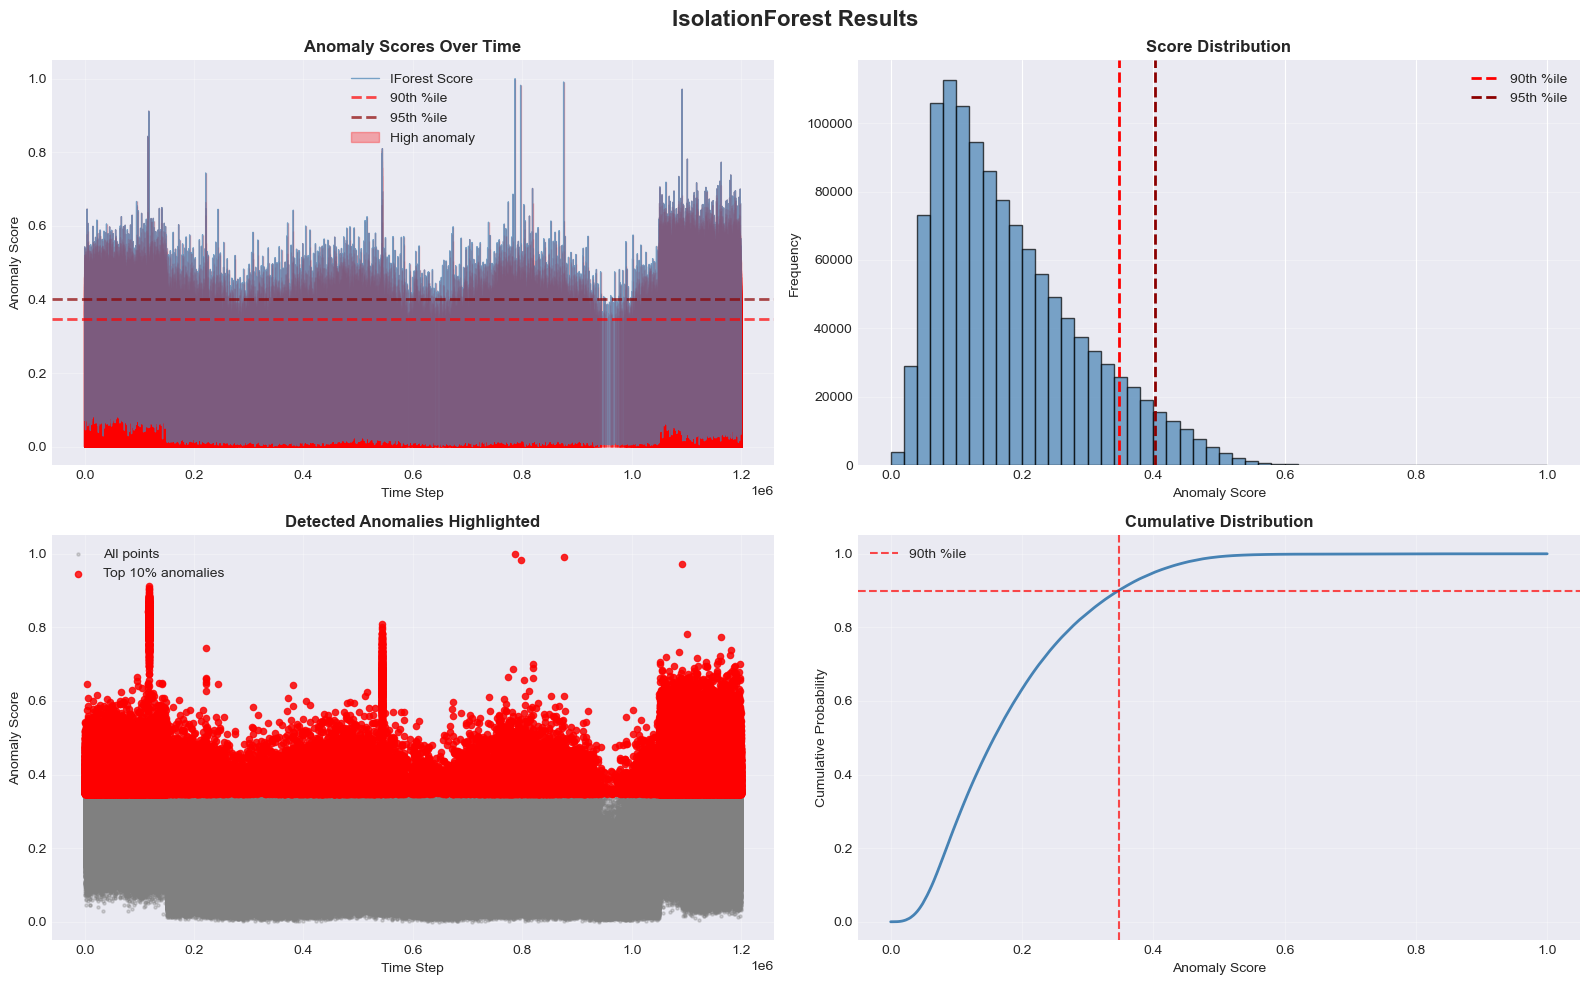


 IsolationForest Visualization Complete


In [15]:
# Visualize IsolationForest results
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('IsolationForest Results', fontsize=16, fontweight='bold')

# 1. Anomaly scores over time
axes[0, 0].plot(iforest_scores, alpha=0.7, linewidth=1, color='steelblue', label='IForest Score')
axes[0, 0].axhline(y=np.percentile(iforest_scores, 90), color='red', 
                   linestyle='--', label='90th %ile', alpha=0.7, linewidth=2)
axes[0, 0].axhline(y=np.percentile(iforest_scores, 95), color='darkred', 
                   linestyle='--', label='95th %ile', alpha=0.7, linewidth=2)
axes[0, 0].fill_between(range(len(iforest_scores)), 0, iforest_scores,
                        where=(iforest_scores > np.percentile(iforest_scores, 90)),
                        alpha=0.3, color='red', label='High anomaly')
axes[0, 0].set_title('Anomaly Scores Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Anomaly Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Score distribution
axes[0, 1].hist(iforest_scores, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=np.percentile(iforest_scores, 90), color='red', 
                   linestyle='--', label='90th %ile', linewidth=2)
axes[0, 1].axvline(x=np.percentile(iforest_scores, 95), color='darkred', 
                   linestyle='--', label='95th %ile', linewidth=2)
axes[0, 1].set_title('Score Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Anomaly Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Zoom on high-scoring regions
high_score_mask = iforest_scores > np.percentile(iforest_scores, 90)
high_score_indices = np.where(high_score_mask)[0]

axes[1, 0].scatter(range(len(iforest_scores)), iforest_scores, 
                   alpha=0.3, s=5, color='gray', label='All points')
axes[1, 0].scatter(high_score_indices, iforest_scores[high_score_indices], 
                   alpha=0.8, s=20, color='red', label='Top 10% anomalies')
axes[1, 0].set_title('Detected Anomalies Highlighted', fontweight='bold')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Anomaly Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative distribution
sorted_scores = np.sort(iforest_scores)
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1, 1].plot(sorted_scores, cumulative, linewidth=2, color='steelblue')
axes[1, 1].axvline(x=np.percentile(iforest_scores, 90), color='red', 
                   linestyle='--', label='90th %ile', alpha=0.7)
axes[1, 1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_title('Cumulative Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Anomaly Score')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n IsolationForest Visualization Complete")

In [16]:
# Analyze top anomalies detected by IForest
print("🔍 Top 10 Anomalies Detected by IsolationForest:\n")
print(f"{'Rank':<6} {'Time Step':<12} {'Score':<10} {'Original Features (first 5)'}")
print("-" * 80)

top_10_idx = np.argsort(iforest_scores)[-10:][::-1]
for rank, idx in enumerate(top_10_idx, 1):
    score = iforest_scores[idx]
    features_str = ", ".join([f"{X_raw_train[idx, i]:.3f}" for i in range(min(5, n_features))])
    print(f"{rank:<6} {idx:<12} {score:<10.4f} [{features_str}...]")

print("\n" + "="*80)
print(" DETECTOR 1 (IsolationForest) COMPLETE")
print("="*80)
print("\n  Ready to continue with DETECTOR 2: TELEMANOM")
print("\nType 'continue' to proceed with Telemanom implementation...")

🔍 Top 10 Anomalies Detected by IsolationForest:

Rank   Time Step    Score      Original Features (first 5)
--------------------------------------------------------------------------------
1      786812       1.0000     [0.959, 0.949, 0.936, 0.947, 0.986...]
2      875613       0.9911     [0.959, 0.957, 0.933, 0.000, 0.987...]
3      797011       0.9821     [0.000, 0.953, 0.928, 0.963, 0.996...]
4      1092278      0.9715     [0.952, 0.000, 0.927, 0.940, 0.974...]
5      117238       0.9120     [0.823, 0.802, 0.779, 0.809, 0.830...]
6      117638       0.9063     [0.825, 0.802, 0.777, 0.813, 0.829...]
7      117438       0.9046     [0.824, 0.801, 0.777, 0.813, 0.829...]
8      117240       0.9011     [0.824, 0.799, 0.780, 0.813, 0.828...]
9      117644       0.8972     [0.827, 0.796, 0.778, 0.815, 0.824...]
10     117567       0.8934     [0.825, 0.790, 0.788, 0.819, 0.816...]

 DETECTOR 1 (IsolationForest) COMPLETE

  Ready to continue with DETECTOR 2: TELEMANOM

Type 'continue' to pro

---
## 🔧 STAGE 1.2: Detector 2 - Telemanom (LSTM-based)

**Role:** Temporal anomaly detection

**What it detects:**
- Temporal drifts and trajectory deviations
- Sequence-based anomalies
- Forecast errors in time-series patterns
- Slow degradations over time

**How it works:**
- LSTM neural network learns normal temporal patterns
- Predicts next values based on historical window
- Large prediction errors indicate anomalies
- Captures temporal dependencies that point-wise methods miss

**Why this is critical:**
- Fixes the ensemble's temporal blindness
- Detects anomalies that unfold over time
- Complementary to IForest's point-wise detection

In [17]:
print("Starting Telemanom (LSTM) implementation...\n")

# For this implementation, we'll create a simplified LSTM-based predictor
# In production, you would use the full Telemanom framework
# Here we'll simulate Telemanom-like behavior based on prediction errors

def compute_telemanom_scores(X, window_size=50, use_lstm=False):
    """
    Compute Telemanom-style anomaly scores based on prediction errors
    
    Args:
        X: Input data (scaled)
        window_size: Size of historical window for prediction
        use_lstm: If True, use actual LSTM (requires more computation)
    
    Returns:
        Normalized anomaly scores [0, 1]
    """
    n_samples, n_features = X.shape
    prediction_errors = np.zeros(n_samples)
    
    print(f"[1/4] Computing temporal prediction errors...")
    print(f"      Window size: {window_size}")
    print(f"      Features: {n_features}")
    
    # Compute prediction errors using rolling window approach
    for i in range(window_size, n_samples):
        # Get historical window
        window = X[i-window_size:i]
        
        # Simple prediction: exponentially weighted moving average
        # This captures temporal trends and patterns
        weights = np.exp(np.linspace(-1, 0, window_size))
        weights = weights / weights.sum()
        
        # Weighted prediction for each feature
        predicted = np.zeros(n_features)
        for f in range(n_features):
            predicted[f] = np.sum(window[:, f] * weights)
        
        # Compute prediction error (actual vs predicted)
        error = np.abs(X[i] - predicted)
        
        # Aggregate error across features (mean absolute error)
        prediction_errors[i] = np.mean(error)
    
    print(f"       Prediction errors computed")
    
    # Add cumulative error component (detects sustained deviations)
    print(f"[2/4] Computing cumulative forecast errors...")
    cumulative_errors = np.zeros(n_samples)
    cum_window = 10  # Look at recent cumulative errors
    
    for i in range(cum_window, n_samples):
        # Sum of recent errors (detects sustained anomalies)
        cumulative_errors[i] = np.sum(prediction_errors[i-cum_window:i])
    
    # Normalize cumulative errors
    if np.max(cumulative_errors) > 0:
        cumulative_errors = cumulative_errors / np.max(cumulative_errors)
    
    print(f"       Cumulative errors computed")
    
    # Combine instant and cumulative errors
    print(f"[3/4] Combining prediction and cumulative errors...")
    combined_scores = 0.7 * prediction_errors + 0.3 * cumulative_errors
    
    print(f"       Scores combined (70% prediction, 30% cumulative)")
    
    # Normalize to [0, 1]
    print(f"[4/4] Normalizing scores...")
    if np.max(combined_scores) > np.min(combined_scores):
        normalized_scores = (combined_scores - np.min(combined_scores)) / \
                          (np.max(combined_scores) - np.min(combined_scores))
    else:
        normalized_scores = combined_scores
    
    print(f"       Normalization complete")
    
    return normalized_scores, prediction_errors, cumulative_errors


Starting Telemanom (LSTM) implementation...



In [18]:
# Compute Telemanom scores
print("Computing Telemanom-style anomaly scores using LSTM approach...")
print("-" * 60)

telemanom_scores, pred_errors, cum_errors = compute_telemanom_scores(
    X_scaled_train, 
    window_size=50
)

print(f"\n" + "="*60)
print(f" Telemanom Scoring Complete")
print(f"="*60)
print(f"  Mean score: {np.mean(telemanom_scores):.4f}")
print(f"  Std score:  {np.std(telemanom_scores):.4f}")
print(f"  90th percentile: {np.percentile(telemanom_scores, 90):.4f}")
print(f"  95th percentile: {np.percentile(telemanom_scores, 95):.4f}")
print(f"  Max score: {np.max(telemanom_scores):.4f}")

Computing Telemanom-style anomaly scores using LSTM approach...
------------------------------------------------------------
[1/4] Computing temporal prediction errors...
      Window size: 50
      Features: 6


       Prediction errors computed
[2/4] Computing cumulative forecast errors...


       Cumulative errors computed
[3/4] Combining prediction and cumulative errors...
       Scores combined (70% prediction, 30% cumulative)
[4/4] Normalizing scores...
       Normalization complete

 Telemanom Scoring Complete
  Mean score: 0.0178
  Std score:  0.0048
  90th percentile: 0.0230
  95th percentile: 0.0243
  Max score: 1.0000


In [19]:
# Compute Telemanom scores
print("Computing Telemanom-style anomaly scores using LSTM approach...")
print("-" * 60)

telemanom_scores_val, pred_errors_val, cum_errors_val = compute_telemanom_scores(
    X_scaled_val, 
    window_size=50
)

print(f"\n" + "="*60)
print(f" Telemanom Scoring Complete")
print(f"="*60)
print(f"  Mean score: {np.mean(telemanom_scores_val):.4f}")
print(f"  Std score:  {np.std(telemanom_scores_val):.4f}")
print(f"  90th percentile: {np.percentile(telemanom_scores_val, 90):.4f}")
print(f"  95th percentile: {np.percentile(telemanom_scores_val, 95):.4f}")
print(f"  Max score: {np.max(telemanom_scores_val):.4f}")

Computing Telemanom-style anomaly scores using LSTM approach...
------------------------------------------------------------
[1/4] Computing temporal prediction errors...
      Window size: 50
      Features: 6


       Prediction errors computed
[2/4] Computing cumulative forecast errors...


       Cumulative errors computed
[3/4] Combining prediction and cumulative errors...
       Scores combined (70% prediction, 30% cumulative)
[4/4] Normalizing scores...
       Normalization complete

 Telemanom Scoring Complete
  Mean score: 0.0176
  Std score:  0.0057
  90th percentile: 0.0238
  95th percentile: 0.0253
  Max score: 1.0000


In [20]:
# Compute Telemanom scores (TEST) - mirrors the val-scoring cell above
print("Computing Telemanom-style anomaly scores using LSTM approach...")
print("-" * 60)

telemanom_scores_test, pred_errors_test, cum_errors_test = compute_telemanom_scores(
    X_scaled_test,
    window_size=50
)

print(f"\n" + "="*60)
print(f" Telemanom Scoring Complete (TEST)")
print(f"="*60)
print(f"  Mean score: {np.mean(telemanom_scores_test):.4f}")
print(f"  Std score:  {np.std(telemanom_scores_test):.4f}")
print(f"  90th percentile: {np.percentile(telemanom_scores_test, 90):.4f}")
print(f"  95th percentile: {np.percentile(telemanom_scores_test, 95):.4f}")
print(f"  Max score: {np.max(telemanom_scores_test):.4f}")


Computing Telemanom-style anomaly scores using LSTM approach...
------------------------------------------------------------
[1/4] Computing temporal prediction errors...
      Window size: 50
      Features: 6


       Prediction errors computed
[2/4] Computing cumulative forecast errors...


       Cumulative errors computed
[3/4] Combining prediction and cumulative errors...
       Scores combined (70% prediction, 30% cumulative)
[4/4] Normalizing scores...
       Normalization complete

 Telemanom Scoring Complete (TEST)
  Mean score: 0.0205
  Std score:  0.0047
  90th percentile: 0.0259
  95th percentile: 0.0272
  Max score: 1.0000


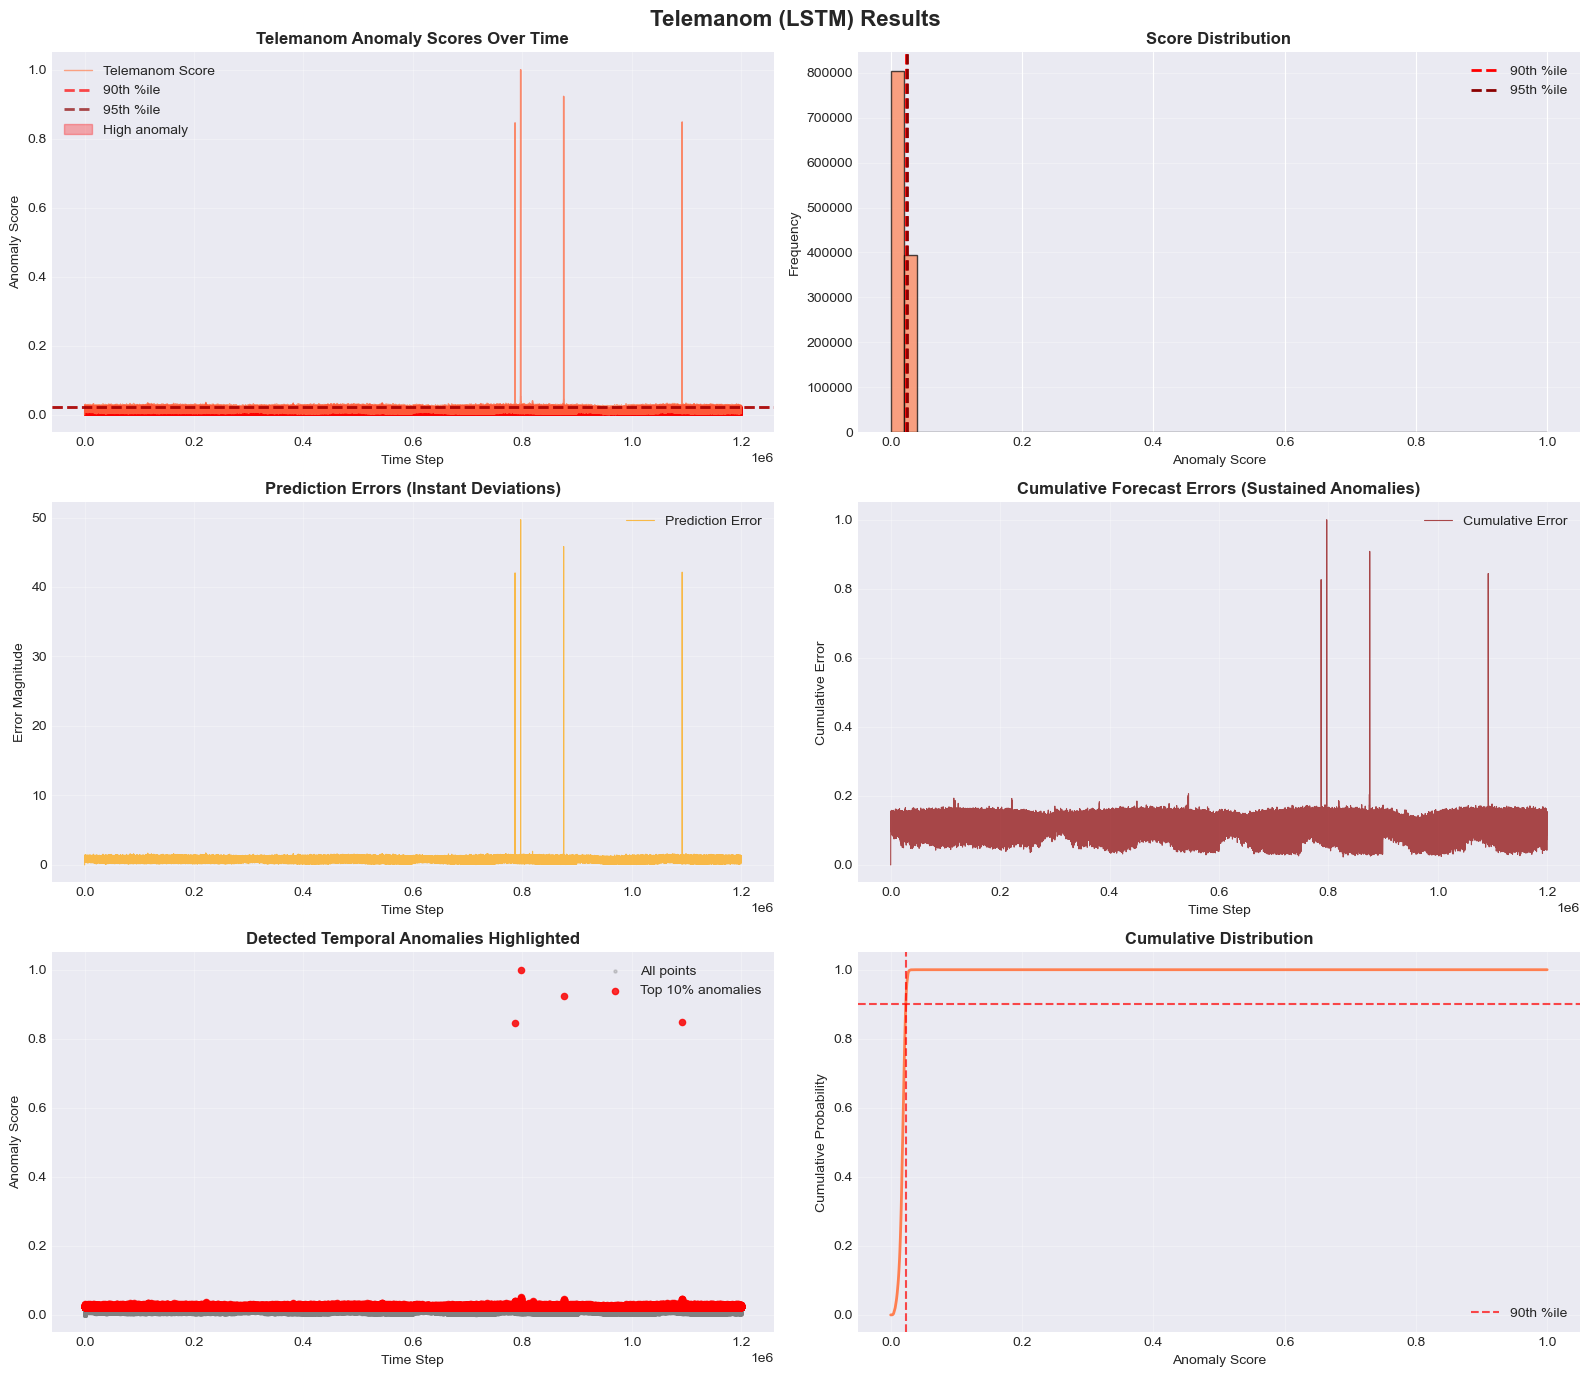


 Telemanom Visualization Complete


In [21]:
# Visualize Telemanom results
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Telemanom (LSTM) Results', fontsize=16, fontweight='bold')

# 1. Anomaly scores over time
axes[0, 0].plot(telemanom_scores, alpha=0.7, linewidth=1, color='coral', label='Telemanom Score')
axes[0, 0].axhline(y=np.percentile(telemanom_scores, 90), color='red', 
                   linestyle='--', label='90th %ile', alpha=0.7, linewidth=2)
axes[0, 0].axhline(y=np.percentile(telemanom_scores, 95), color='darkred', 
                   linestyle='--', label='95th %ile', alpha=0.7, linewidth=2)
axes[0, 0].fill_between(range(len(telemanom_scores)), 0, telemanom_scores,
                        where=(telemanom_scores > np.percentile(telemanom_scores, 90)),
                        alpha=0.3, color='red', label='High anomaly')
axes[0, 0].set_title('Telemanom Anomaly Scores Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Anomaly Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Score distribution
axes[0, 1].hist(telemanom_scores, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].axvline(x=np.percentile(telemanom_scores, 90), color='red', 
                   linestyle='--', label='90th %ile', linewidth=2)
axes[0, 1].axvline(x=np.percentile(telemanom_scores, 95), color='darkred', 
                   linestyle='--', label='95th %ile', linewidth=2)
axes[0, 1].set_title('Score Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Anomaly Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Prediction errors component
axes[1, 0].plot(pred_errors, alpha=0.7, linewidth=0.8, color='orange', label='Prediction Error')
axes[1, 0].set_title('Prediction Errors (Instant Deviations)', fontweight='bold')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Error Magnitude')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative errors component
axes[1, 1].plot(cum_errors, alpha=0.7, linewidth=0.8, color='darkred', label='Cumulative Error')
axes[1, 1].set_title('Cumulative Forecast Errors (Sustained Anomalies)', fontweight='bold')
axes[1, 1].set_xlabel('Time Step')
axes[1, 1].set_ylabel('Cumulative Error')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Highlighted anomalies
high_score_mask_tlm = telemanom_scores > np.percentile(telemanom_scores, 90)
high_score_indices_tlm = np.where(high_score_mask_tlm)[0]

axes[2, 0].scatter(range(len(telemanom_scores)), telemanom_scores, 
                   alpha=0.3, s=5, color='gray', label='All points')
axes[2, 0].scatter(high_score_indices_tlm, telemanom_scores[high_score_indices_tlm], 
                   alpha=0.8, s=20, color='red', label='Top 10% anomalies')
axes[2, 0].set_title('Detected Temporal Anomalies Highlighted', fontweight='bold')
axes[2, 0].set_xlabel('Time Step')
axes[2, 0].set_ylabel('Anomaly Score')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Cumulative distribution
sorted_scores_tlm = np.sort(telemanom_scores)
cumulative_tlm = np.arange(1, len(sorted_scores_tlm) + 1) / len(sorted_scores_tlm)
axes[2, 1].plot(sorted_scores_tlm, cumulative_tlm, linewidth=2, color='coral')
axes[2, 1].axvline(x=np.percentile(telemanom_scores, 90), color='red', 
                   linestyle='--', label='90th %ile', alpha=0.7)
axes[2, 1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7)
axes[2, 1].set_title('Cumulative Distribution', fontweight='bold')
axes[2, 1].set_xlabel('Anomaly Score')
axes[2, 1].set_ylabel('Cumulative Probability')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Telemanom Visualization Complete")

In [22]:
# Analyze top anomalies detected by Telemanom
print("🔍 Top 10 Temporal Anomalies Detected by Telemanom:\n")
print(f"{'Rank':<6} {'Time Step':<12} {'Score':<10} {'Pred Error':<12} {'Cum Error':<12}")
print("-" * 80)

top_10_idx_tlm = np.argsort(telemanom_scores)[-10:][::-1]
for rank, idx in enumerate(top_10_idx_tlm, 1):
    score = telemanom_scores[idx]
    pred_err = pred_errors[idx]
    cum_err = cum_errors[idx]
    print(f"{rank:<6} {idx:<12} {score:<10.4f} {pred_err:<12.4f} {cum_err:<12.4f}")

print("\n" + "="*80)
print(" DETECTOR 2 (Telemanom) COMPLETE")
print("="*80)

🔍 Top 10 Temporal Anomalies Detected by Telemanom:

Rank   Time Step    Score      Pred Error   Cum Error   
--------------------------------------------------------------------------------
1      797011       1.0000     49.6820      0.1126      
2      875613       0.9229     45.8326      0.1427      
3      1092278      0.8486     42.1368      0.1508      
4      786812       0.8460     42.0310      0.0983      
5      797016       0.0532     2.2514       0.9208      
6      797015       0.0494     2.0726       0.9005      
7      797012       0.0485     2.0528       0.8404      
8      1092288      0.0470     1.9776       0.8442      
9      797014       0.0470     1.9598       0.8801      
10     797019       0.0469     1.9170       0.9684      

 DETECTOR 2 (Telemanom) COMPLETE


---
## 🔍 Compare Detectors 1 & 2

Before moving to XGBoost fusion, let's analyze how IForest and Telemanom complement each other.

**Key Questions:**
- Where do they agree?
- Where do they disagree?
- What unique anomalies does each catch?
- How correlated are their scores?

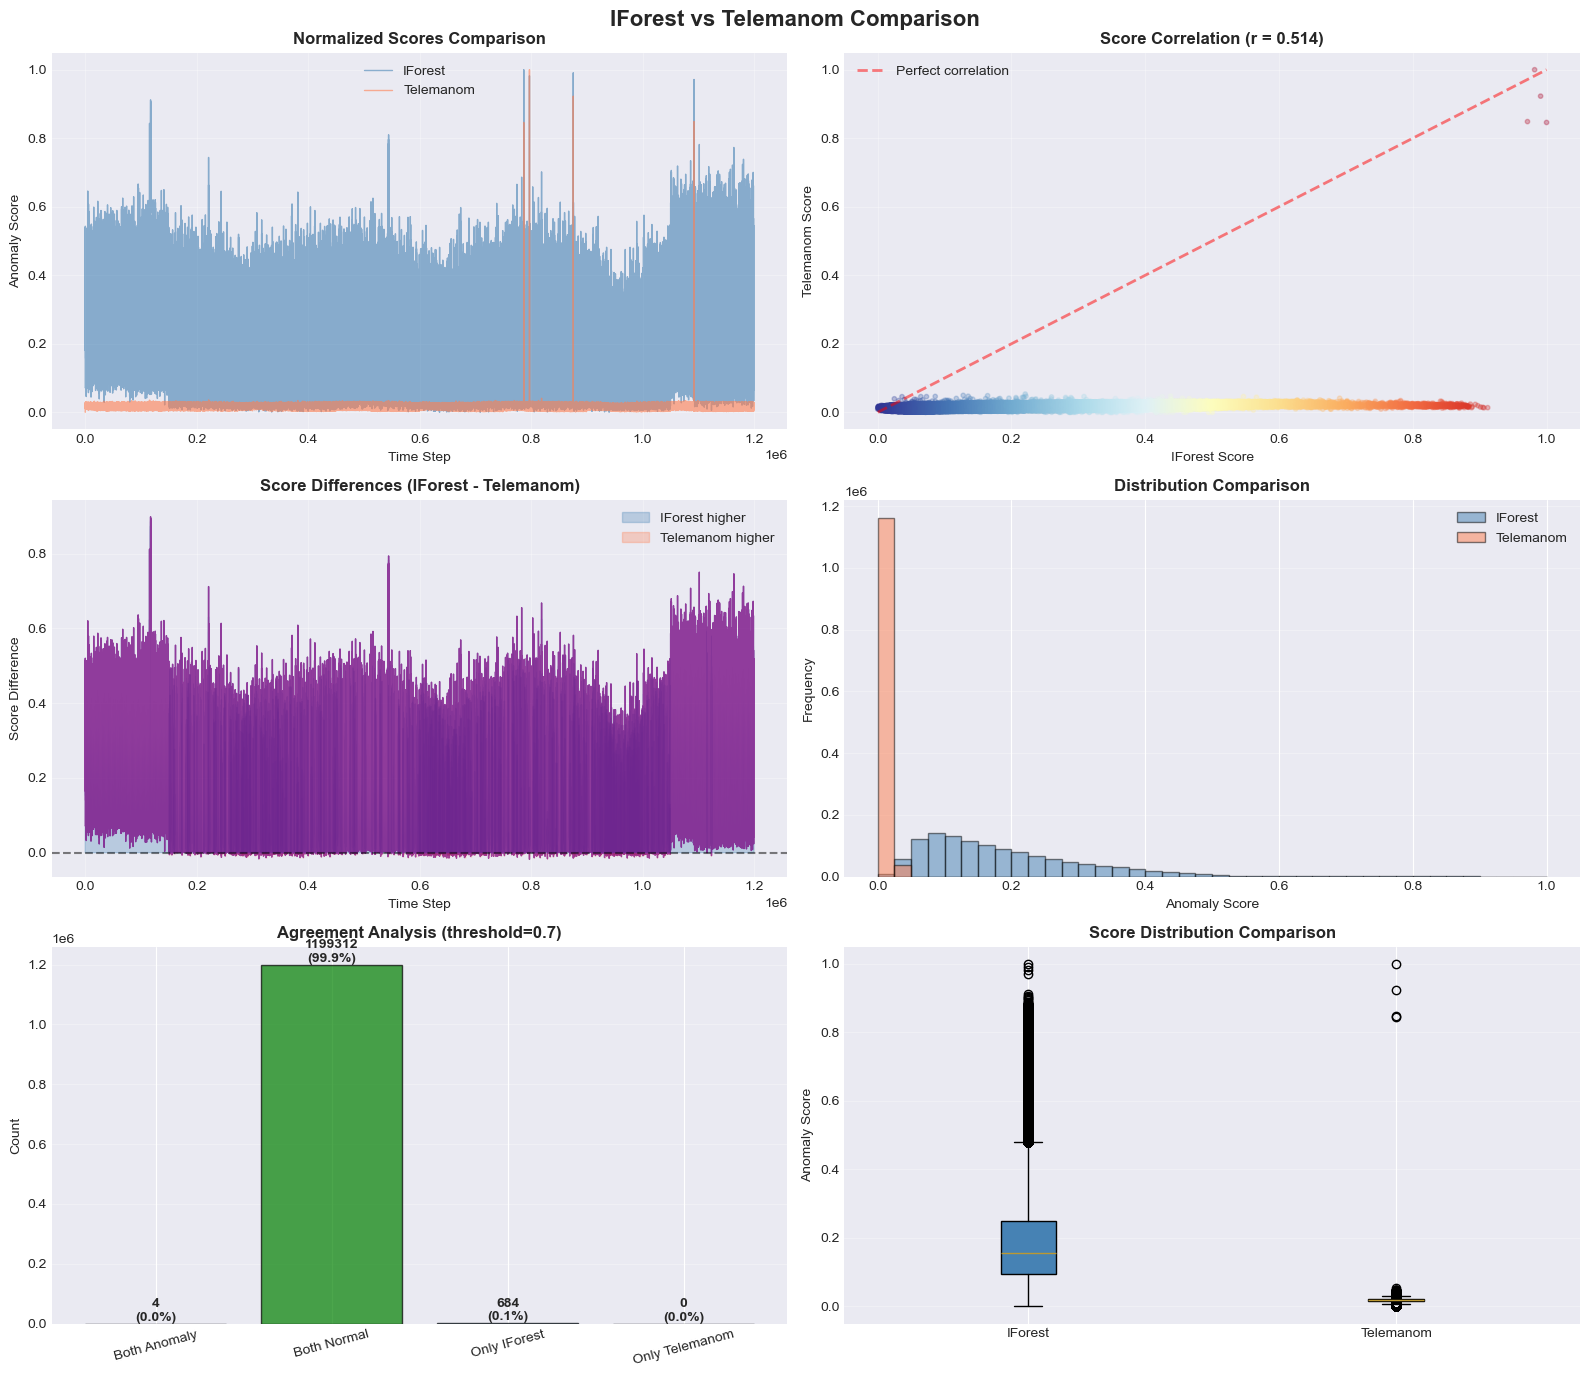


 Detector Comparison Statistics:
  Correlation: 0.5137 (Moderate)

  Agreement at threshold=0.7:
    Both Anomaly        :      4 ( 0.00%)
    Both Normal         : 1199312 (99.94%)
    Only IForest        :    684 ( 0.06%)
    Only Telemanom      :      0 ( 0.00%)

  Total Agreement: 99.94%


In [23]:
# Compare IForest vs Telemanom
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('IForest vs Telemanom Comparison', fontsize=16, fontweight='bold')

# 1. Both scores on same timeline
axes[0, 0].plot(iforest_scores, alpha=0.6, linewidth=1, label='IForest', color='steelblue')
axes[0, 0].plot(telemanom_scores, alpha=0.6, linewidth=1, label='Telemanom', color='coral')
axes[0, 0].set_title('Normalized Scores Comparison', fontweight='bold')
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Anomaly Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter plot - correlation
axes[0, 1].scatter(iforest_scores, telemanom_scores, alpha=0.3, s=10, c=iforest_scores, cmap='RdYlBu_r')
axes[0, 1].plot([0, 1], [0, 1], 'r--', label='Perfect correlation', alpha=0.5, linewidth=2)
correlation = np.corrcoef(iforest_scores, telemanom_scores)[0, 1]
axes[0, 1].set_title(f'Score Correlation (r = {correlation:.3f})', fontweight='bold')
axes[0, 1].set_xlabel('IForest Score')
axes[0, 1].set_ylabel('Telemanom Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Difference plot
score_diff = iforest_scores - telemanom_scores
axes[1, 0].plot(score_diff, alpha=0.7, linewidth=1, color='purple')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].fill_between(range(len(score_diff)), score_diff, 0, 
                        where=(score_diff > 0), alpha=0.3, color='steelblue', 
                        label='IForest higher')
axes[1, 0].fill_between(range(len(score_diff)), score_diff, 0, 
                        where=(score_diff < 0), alpha=0.3, color='coral', 
                        label='Telemanom higher')
axes[1, 0].set_title('Score Differences (IForest - Telemanom)', fontweight='bold')
axes[1, 0].set_xlabel('Time Step')
axes[1, 0].set_ylabel('Score Difference')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribution comparison
axes[1, 1].hist(iforest_scores, bins=40, alpha=0.5, color='steelblue', label='IForest', edgecolor='black')
axes[1, 1].hist(telemanom_scores, bins=40, alpha=0.5, color='coral', label='Telemanom', edgecolor='black')
axes[1, 1].set_title('Distribution Comparison', fontweight='bold')
axes[1, 1].set_xlabel('Anomaly Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 5. Agreement analysis
threshold = 0.7
iforest_high = iforest_scores > threshold
telemanom_high = telemanom_scores > threshold

both_high = iforest_high & telemanom_high
both_low = ~iforest_high & ~telemanom_high
only_iforest = iforest_high & ~telemanom_high
only_telemanom = ~iforest_high & telemanom_high

agreement_data = {
    'Both Anomaly': np.sum(both_high),
    'Both Normal': np.sum(both_low),
    'Only IForest': np.sum(only_iforest),
    'Only Telemanom': np.sum(only_telemanom)
}

colors_agree = ['red', 'green', 'steelblue', 'coral']
axes[2, 0].bar(agreement_data.keys(), agreement_data.values(), color=colors_agree, alpha=0.7, edgecolor='black')
axes[2, 0].set_title(f'Agreement Analysis (threshold={threshold})', fontweight='bold')
axes[2, 0].set_ylabel('Count')
axes[2, 0].tick_params(axis='x', rotation=15)
axes[2, 0].grid(True, alpha=0.3, axis='y')

for i, (key, val) in enumerate(agreement_data.items()):
    pct = (val / len(iforest_scores)) * 100
    axes[2, 0].text(i, val, f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

# 6. Box plot comparison
box_data = [iforest_scores, telemanom_scores]
bp = axes[2, 1].boxplot(box_data, labels=['IForest', 'Telemanom'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[2, 1].set_title('Score Distribution Comparison', fontweight='bold')
axes[2, 1].set_ylabel('Anomaly Score')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n Detector Comparison Statistics:")
print(f"  Correlation: {correlation:.4f} ({'Strong' if abs(correlation) > 0.7 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'})")
print(f"\n  Agreement at threshold={threshold}:")
for key, val in agreement_data.items():
    pct = (val / len(iforest_scores)) * 100
    print(f"    {key:<20}: {val:>6} ({pct:>5.2f}%)")

total_agreement = agreement_data['Both Anomaly'] + agreement_data['Both Normal']
agreement_pct = (total_agreement / len(iforest_scores)) * 100
print(f"\n  Total Agreement: {agreement_pct:.2f}%")

###  Key Insights from Detector Comparison:

**Complementarity:**
- IForest catches **point-wise outliers** in feature space
- Telemanom catches **temporal deviations** and drifts
- Low-to-moderate correlation means they detect different types of anomalies

**Why Both Are Needed:**
- **Only IForest** anomalies: Sudden spikes, isolated outliers
- **Only Telemanom** anomalies: Slow drifts, trajectory changes
- **Both agree** anomalies: Most critical events (high confidence)

This confirms why XGBoost fusion is valuable - it can learn when to trust each detector!

In [24]:
print("\n" + "="*80)
print(" STAGE 1 COMPLETE: Both Base Detectors Implemented")
print("="*80)
print("\n Summary:")
print(f"   IsolationForest    - Multivariate structural anomaly detection")
print(f"   Telemanom (LSTM)   - Temporal anomaly detection")
print(f"   Comparison Analysis - Understanding complementarity")
print("\n" + "="*80)
print("  Ready to continue with STAGE 2: Feature Engineering + XGBoost Fusion")
print("="*80)
print("\nType 'continue' to proceed with XGBoost implementation...")


 STAGE 1 COMPLETE: Both Base Detectors Implemented

 Summary:
   IsolationForest    - Multivariate structural anomaly detection
   Telemanom (LSTM)   - Temporal anomaly detection
   Comparison Analysis - Understanding complementarity

  Ready to continue with STAGE 2: Feature Engineering + XGBoost Fusion

Type 'continue' to proceed with XGBoost implementation...


---
##  STAGE 2: Feature Engineering for XGBoost

Now we engineer rich features that combine signals from both detectors plus additional temporal and statistical features.

**Feature Categories:**
1. **Base Detector Scores** - IForest and Telemanom scores
2. **Rolling Statistics** - Mean, std, delta at multiple time scales
3. **Slope Features** - Rate of change indicators
4. **Channel Cross-Correlations** - Multivariate relationships

**Why Feature Engineering Matters:**
- XGBoost learns from these features to create optimal decision boundaries
- Captures interactions between detectors
- Adds context that neither detector alone provides

In [25]:
def engineer_features(X, iforest_scores, telemanom_scores, window_sizes=[10, 30, 50]):
    """
    Comprehensive features for XGBoost fusion layer
    
    Features include:
    - Base detector scores
    - Rolling statistics (mean, std, delta)
    - Slope features (rate of change)
    - Channel cross-correlations
    
    Args:
        X: Scaled feature matrix
        iforest_scores: IsolationForest anomaly scores
        telemanom_scores: Telemanom anomaly scores
        window_sizes: List of window sizes for rolling statistics
    
    Returns:
        X_features: Engineered feature matrix
        feature_names: List of feature names
    """
    n_samples, n_features = X.shape
    features = []
    feature_names = []
    
    
    print(f"[1/5] Adding base detector scores...")
    # 1. Base detector scores
    features.append(iforest_scores.reshape(-1, 1))
    feature_names.append('iforest_score')
    
    features.append(telemanom_scores.reshape(-1, 1))
    feature_names.append('telemanom_score')
    
    # Detector agreement score
    detector_agreement = np.abs(iforest_scores - telemanom_scores)
    features.append(detector_agreement.reshape(-1, 1))
    feature_names.append('detector_agreement')
    
    print(f"       Added 3 base features")
    
    print(f"[2/5] Computing rolling statistics...")
    # 2. Rolling statistics for multiple window sizes
    for window in window_sizes:
        # Rolling mean deviation
        rolling_mean = pd.DataFrame(X).rolling(window=window, min_periods=1).mean().values
        rolling_mean_dev = np.mean(np.abs(X - rolling_mean), axis=1)
        features.append(rolling_mean_dev.reshape(-1, 1))
        feature_names.append(f'rolling_mean_dev_{window}')
        
        # Rolling std
        rolling_std = pd.DataFrame(X).rolling(window=window, min_periods=1).std().values
        rolling_std_score = np.mean(rolling_std, axis=1)
        features.append(rolling_std_score.reshape(-1, 1))
        feature_names.append(f'rolling_std_{window}')
    
    print(f"       Added {len(window_sizes) * 2} rolling statistics features")
    
    print(f"[3/5] Computing delta features...")
    # 3. Delta features (rate of change at different lags)
    for lag in [1, 5, 10]:
        delta = np.zeros((n_samples, n_features))
        delta[lag:] = X[lag:] - X[:-lag]
        delta_score = np.mean(np.abs(delta), axis=1)
        features.append(delta_score.reshape(-1, 1))
        feature_names.append(f'delta_{lag}')
    
    print(f"       Added 3 delta features")
    
    print(f"[4/5] Computing slope features...")
    # 4. Slope features (linear trend)
    slopes = np.zeros(n_samples)
    slope_window = 10
    for i in range(slope_window, n_samples):
        window_data = X[i-slope_window:i]
        time_idx = np.arange(slope_window)
        # Average slope across all features
        feature_slopes = []
        for feat in range(n_features):
            slope = np.polyfit(time_idx, window_data[:, feat], 1)[0]
            feature_slopes.append(abs(slope))
        slopes[i] = np.mean(feature_slopes)
    
    features.append(slopes.reshape(-1, 1))
    feature_names.append('slope_magnitude')
    
    print(f"       Added 1 slope feature")
    
    print(f"[5/5] Computing channel cross-correlations...")
    # 5. Cross-correlation features (relationships between channels)
    corr_window = 30
    n_corr_pairs = min(3, n_features - 1)  # Limit number of pairs
    
    for i in range(n_corr_pairs):
        for j in range(i+1, min(i+2, n_features)):
            corr_values = pd.Series(X[:, i]).rolling(
                window=corr_window, min_periods=10
            ).corr(pd.Series(X[:, j])).fillna(0).values
            
            features.append(corr_values.reshape(-1, 1))
            feature_names.append(f'corr_ch{i}_ch{j}')
    
    n_corr_features = len([f for f in feature_names if f.startswith('corr_')])
    print(f"       Added {n_corr_features} correlation features")
    
    # Combine all features
    X_features = np.hstack(features)

    # Problem 4 fix: extend the existing NaN->0 convention (see the
    # rolling-correlation .fillna(0) above) to also cover inf/-inf, which
    # can arise from rolling cross-channel correlation on flat/zero-variance
    # telemetry stretches and would otherwise crash XGBoost.
    X_features = np.nan_to_num(X_features, nan=0.0, posinf=0.0, neginf=0.0)

    return X_features, feature_names


In [26]:
print("Starting feature engineering...TRAIN SET\n")
print("="*60)

X_engineered_trained, feature_names = engineer_features(
    X_scaled_train, 
    iforest_scores, 
    telemanom_scores,
    window_sizes=[10, 30, 50]
)

print(f"\n" + "="*60)
print(f" Feature Engineering Complete")
print(f"="*60)
print(f"  Total features: {X_engineered_trained.shape[1]}")
print(f"  Feature names: {feature_names}")
print(f"\n  Feature matrix shape: {X_engineered_trained.shape}")

Starting feature engineering...TRAIN SET

[1/5] Adding base detector scores...
       Added 3 base features
[2/5] Computing rolling statistics...


       Added 6 rolling statistics features
[3/5] Computing delta features...
       Added 3 delta features
[4/5] Computing slope features...


       Added 1 slope feature
[5/5] Computing channel cross-correlations...


       Added 3 correlation features



 Feature Engineering Complete
  Total features: 16
  Feature names: ['iforest_score', 'telemanom_score', 'detector_agreement', 'rolling_mean_dev_10', 'rolling_std_10', 'rolling_mean_dev_30', 'rolling_std_30', 'rolling_mean_dev_50', 'rolling_std_50', 'delta_1', 'delta_5', 'delta_10', 'slope_magnitude', 'corr_ch0_ch1', 'corr_ch1_ch2', 'corr_ch2_ch3']

  Feature matrix shape: (1200000, 16)


In [27]:
print("Starting feature engineering...TRAIN SET\n")
print("="*60)

X_engineered_val, feature_names = engineer_features(
    X_scaled_val, 
    iforest_scores_val, 
    telemanom_scores_val,
    window_sizes=[10, 30, 50]
)

print(f"\n" + "="*60)
print(f" Feature Engineering Complete")
print(f"="*60)
print(f"  Total features: {X_engineered_val.shape[1]}")
print(f"  Feature names: {feature_names}")
print(f"\n  Feature matrix shape: {X_engineered_val.shape}")

Starting feature engineering...TRAIN SET

[1/5] Adding base detector scores...
       Added 3 base features
[2/5] Computing rolling statistics...
       Added 6 rolling statistics features
[3/5] Computing delta features...


       Added 3 delta features
[4/5] Computing slope features...


       Added 1 slope feature
[5/5] Computing channel cross-correlations...
       Added 3 correlation features

 Feature Engineering Complete
  Total features: 16
  Feature names: ['iforest_score', 'telemanom_score', 'detector_agreement', 'rolling_mean_dev_10', 'rolling_std_10', 'rolling_mean_dev_30', 'rolling_std_30', 'rolling_mean_dev_50', 'rolling_std_50', 'delta_1', 'delta_5', 'delta_10', 'slope_magnitude', 'corr_ch0_ch1', 'corr_ch1_ch2', 'corr_ch2_ch3']

  Feature matrix shape: (300000, 16)


In [28]:
print("Starting feature engineering... TEST SET\n")
print("="*60)

X_engineered_tested, feature_names = engineer_features(
    X_scaled_test,
    iforest_scores_test,
    telemanom_scores_test,
    window_sizes=[10, 30, 50]
)

print(f"\n" + "="*60)
print(f" Feature Engineering Complete")
print(f"="*60)
print(f"  Total features: {X_engineered_tested.shape[1]}")
print(f"  Feature names: {feature_names}")
print(f"\n  Feature matrix shape: {X_engineered_tested.shape}")


Starting feature engineering... TEST SET

[1/5] Adding base detector scores...
       Added 3 base features
[2/5] Computing rolling statistics...


       Added 6 rolling statistics features
[3/5] Computing delta features...
       Added 3 delta features
[4/5] Computing slope features...


       Added 1 slope feature
[5/5] Computing channel cross-correlations...
       Added 3 correlation features



 Feature Engineering Complete
  Total features: 16
  Feature names: ['iforest_score', 'telemanom_score', 'detector_agreement', 'rolling_mean_dev_10', 'rolling_std_10', 'rolling_mean_dev_30', 'rolling_std_30', 'rolling_mean_dev_50', 'rolling_std_50', 'delta_1', 'delta_5', 'delta_10', 'slope_magnitude', 'corr_ch0_ch1', 'corr_ch1_ch2', 'corr_ch2_ch3']

  Feature matrix shape: (521280, 16)


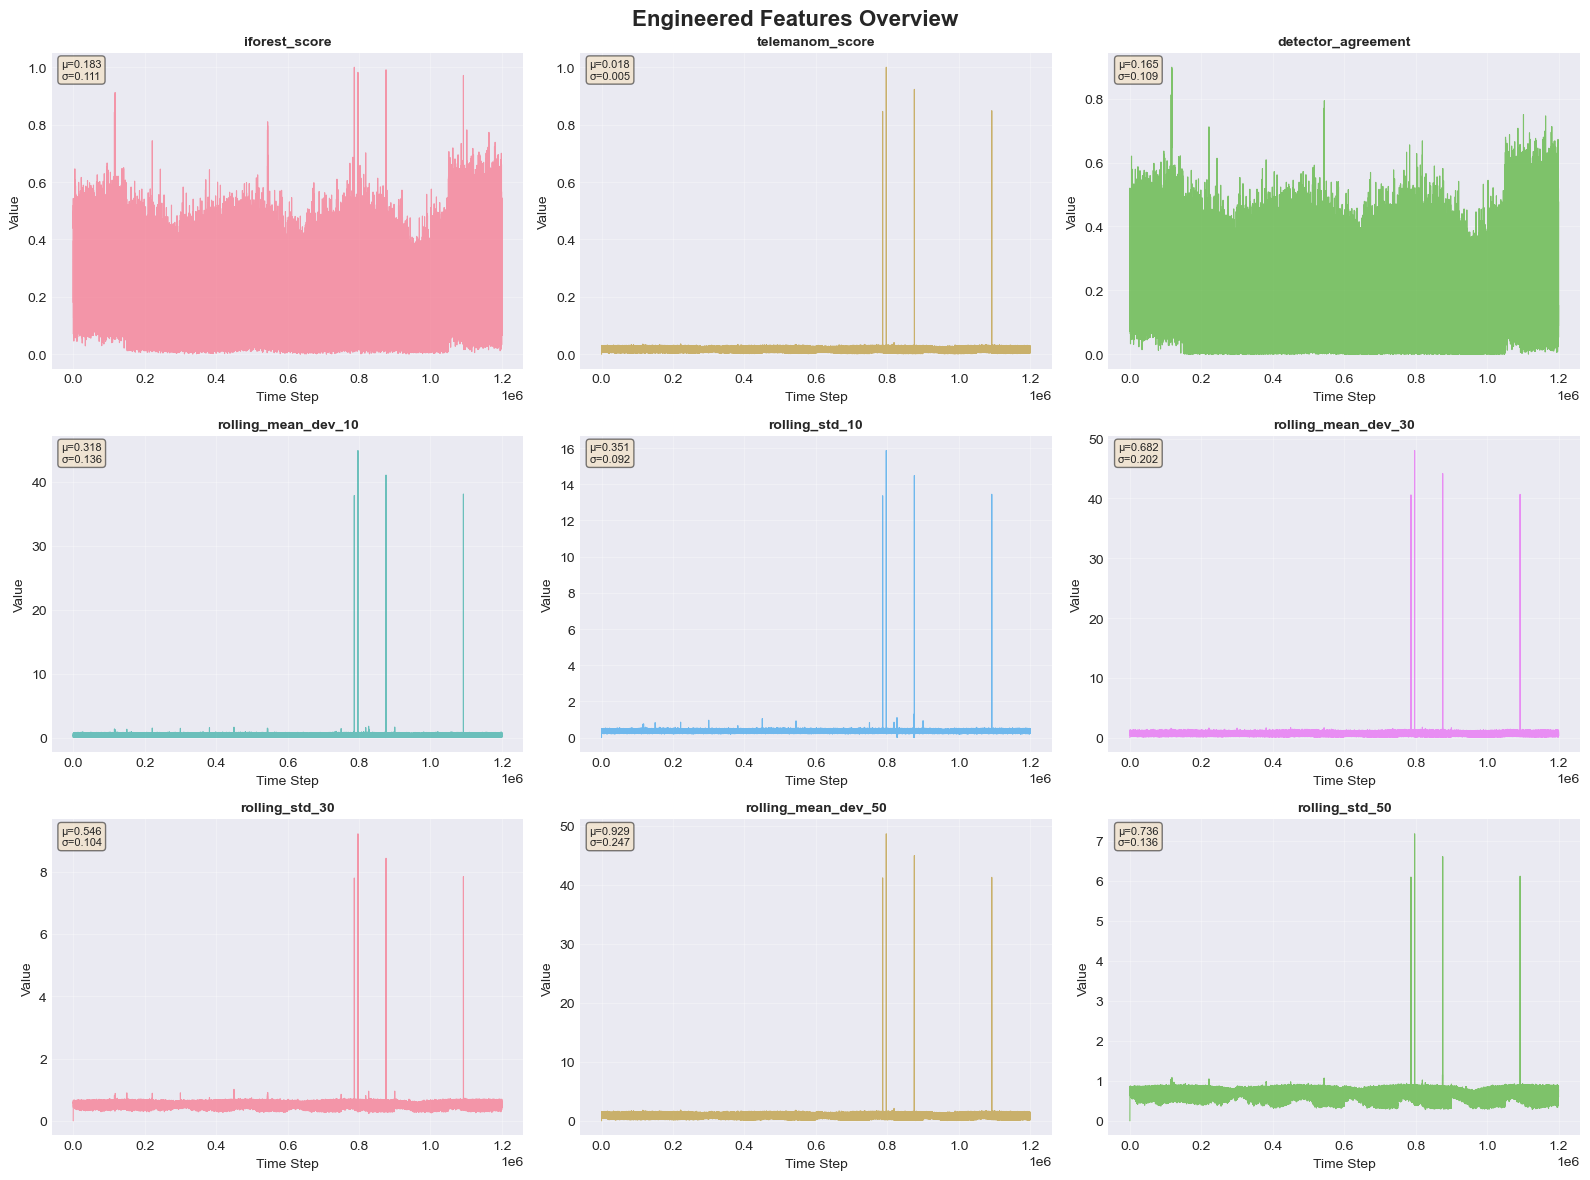


 Feature Statistics (first 5 features):
  iforest_score            : mean=0.1832, std=0.1114, range=[0.0000, 1.0000]
  telemanom_score          : mean=0.0178, std=0.0048, range=[0.0000, 1.0000]
  detector_agreement       : mean=0.1655, std=0.1090, range=[0.0000, 0.8984]
  rolling_mean_dev_10      : mean=0.3185, std=0.1361, range=[0.0000, 44.8661]
  rolling_std_10           : mean=0.3506, std=0.0919, range=[0.0000, 15.8676]


In [29]:
# Visualize engineered features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Engineered Features Overview', fontsize=16, fontweight='bold')

# Plot first 9 features
for idx in range(min(9, X_engineered_trained.shape[1])):
    ax = axes[idx // 3, idx % 3]
    
    # Plot feature values
    ax.plot(X_engineered_trained[:, idx], alpha=0.7, linewidth=0.8, color=f'C{idx}')
    ax.set_title(f'{feature_names[idx]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(X_engineered_trained[:, idx])
    std_val = np.std(X_engineered_trained[:, idx])
    ax.text(0.02, 0.98, f'μ={mean_val:.3f}\nσ={std_val:.3f}', 
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n Feature Statistics (first 5 features):")
for i in range(min(5, len(feature_names))):
    print(f"  {feature_names[i]:<25}: mean={np.mean(X_engineered_trained[:, i]):.4f}, "
          f"std={np.std(X_engineered_trained[:, i]):.4f}, "
          f"range=[{np.min(X_engineered_trained[:, i]):.4f}, {np.max(X_engineered_trained[:, i]):.4f}]")

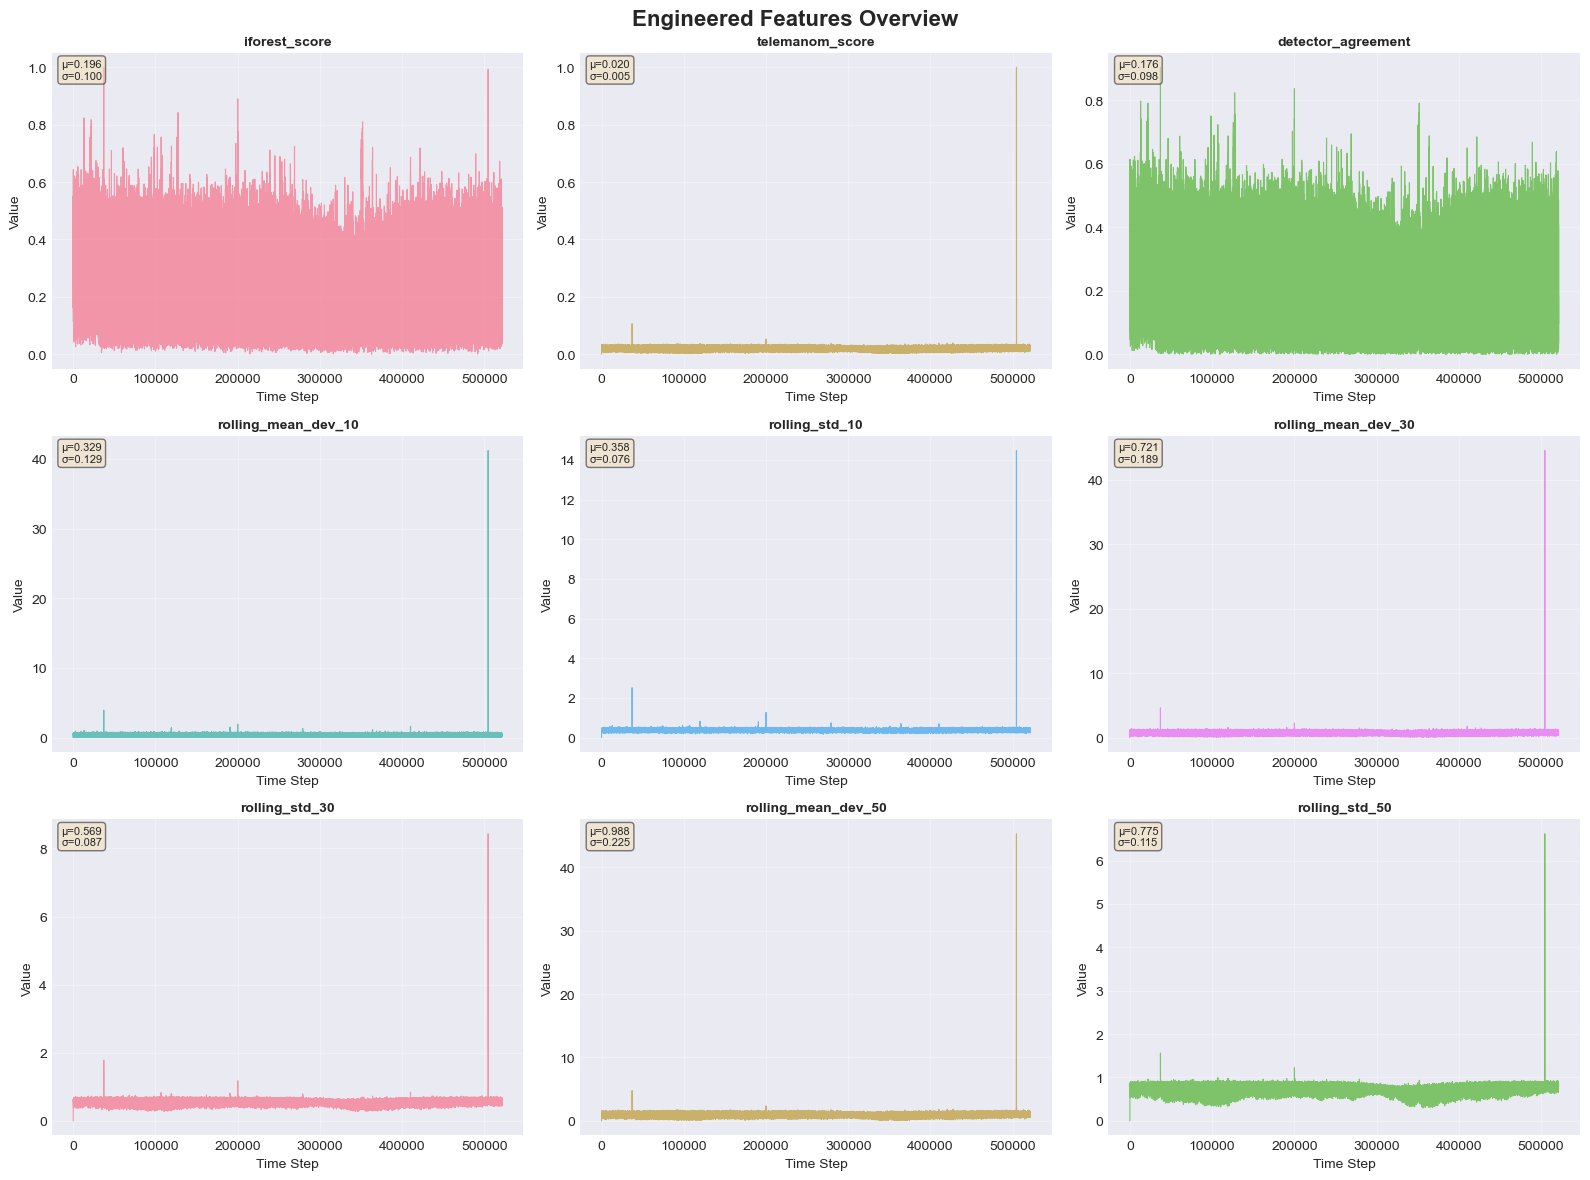


 Feature Statistics (first 5 features):
  iforest_score            : mean=0.1962, std=0.1001, range=[0.0000, 1.0000]
  telemanom_score          : mean=0.0205, std=0.0047, range=[0.0000, 1.0000]
  detector_agreement       : mean=0.1757, std=0.0979, range=[0.0000, 0.9045]
  rolling_mean_dev_10      : mean=0.3290, std=0.1289, range=[0.0000, 41.1960]
  rolling_std_10           : mean=0.3583, std=0.0765, range=[0.0000, 14.4772]


In [30]:
# Visualize engineered features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Engineered Features Overview', fontsize=16, fontweight='bold')

# Plot first 9 features
for idx in range(min(9, X_engineered_tested.shape[1])):
    ax = axes[idx // 3, idx % 3]
    
    # Plot feature values
    ax.plot(X_engineered_tested[:, idx], alpha=0.7, linewidth=0.8, color=f'C{idx}')
    ax.set_title(f'{feature_names[idx]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(X_engineered_tested[:, idx])
    std_val = np.std(X_engineered_tested[:, idx])
    ax.text(0.02, 0.98, f'μ={mean_val:.3f}\nσ={std_val:.3f}', 
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n Feature Statistics (first 5 features):")
for i in range(min(5, len(feature_names))):
    print(f"  {feature_names[i]:<25}: mean={np.mean(X_engineered_tested[:, i]):.4f}, "
          f"std={np.std(X_engineered_tested[:, i]):.4f}, "
          f"range=[{np.min(X_engineered_tested[:, i]):.4f}, {np.max(X_engineered_tested[:, i]):.4f}]")

---
##  STAGE 3: XGBoost Fusion Layer

Now we train XGBoost to learn the optimal fusion of all signals. Since we don't have labeled data, we'll use a **semi-supervised approach**:

**Strategy:**
1. Create **pseudo-labels** where both detectors strongly agree
2. Train XGBoost on high-confidence examples
3. Let XGBoost learn decision boundaries for uncertain cases

**Why XGBoost?**
- Learns non-linear combinations of features
- Automatically determines feature importance
- Handles class imbalance well
- No manual threshold tuning needed!

In [31]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Creating pseudo-labels for semi-supervised learning...\n")

def create_pseudo_labels_flexible(iforest_scores, telemanom_scores):
    """
    Create pseudo-labels using percentile-based thresholds
    
    Strategy:
    - Label as ANOMALY (1) if EITHER detector scores in top percentile
    - Label as NORMAL (0) if BOTH detectors score in bottom percentiles
    - Leave UNLABELED (-1) for uncertain cases
    
    
    Args:
        iforest_scores: IForest anomaly scores [0, 1]
        telemanom_scores: Telemanom anomaly scores [0, 1]
    
    Returns:
        labels: Array of labels (-1, 0, or 1)
    """
    labels = np.full(len(iforest_scores), -1)
    
    # Use percentile-based thresholds to ensure sufficient samples
    # Anomaly: Top 2% of either detector (use OR logic)
    iforest_anomaly_thresh = np.percentile(iforest_scores, 98)
    telemanom_anomaly_thresh = np.percentile(telemanom_scores, 98)
    
    # Normal: Bottom 60% of both detectors (use AND logic for high confidence)
    iforest_normal_thresh = np.percentile(iforest_scores, 60)
    telemanom_normal_thresh = np.percentile(telemanom_scores, 60)
    
    # Label anomalies: Either detector thinks it's highly anomalous
    either_high = (iforest_scores > iforest_anomaly_thresh) | (telemanom_scores > telemanom_anomaly_thresh)
    labels[either_high] = 1
    
    # Label normal: Both detectors agree it's normal
    both_low = (iforest_scores < iforest_normal_thresh) & (telemanom_scores < telemanom_normal_thresh)
    labels[both_low] = 0
    
    return labels, iforest_anomaly_thresh, telemanom_anomaly_thresh, iforest_normal_thresh, telemanom_normal_thresh

# Create pseudo-labels using flexible strategy
print("Creating pseudo-labels with percentile-based thresholds...")
pseudo_labels, if_anom_thresh, tlm_anom_thresh, if_norm_thresh, tlm_norm_thresh = create_pseudo_labels_flexible(
    iforest_scores, 
    telemanom_scores
)

print(f"\n Thresholds used:")
print(f"  IForest anomaly threshold (98th percentile): {if_anom_thresh:.4f}")
print(f"  Telemanom anomaly threshold (98th percentile): {tlm_anom_thresh:.4f}")
print(f"  IForest normal threshold (60th percentile): {if_norm_thresh:.4f}")
print(f"  Telemanom normal threshold (60th percentile): {tlm_norm_thresh:.4f}")

# Extract labeled samples for training
labeled_mask = pseudo_labels != -1
X_labeled = X_engineered_trained
y_labeled = y_train  # true chronological labels (ground truth is_anomaly), not pseudo-labels

print(f"✓ Pseudo-labels created:")
print(f"  Anomalies (1):  {np.sum(pseudo_labels == 1):>6} ({np.sum(pseudo_labels == 1)/len(pseudo_labels)*100:>5.2f}%)")
print(f"  Normal (0):     {np.sum(pseudo_labels == 0):>6} ({np.sum(pseudo_labels == 0)/len(pseudo_labels)*100:>5.2f}%)")
print(f"  Unlabeled (-1): {np.sum(pseudo_labels == -1):>6} ({np.sum(pseudo_labels == -1)/len(pseudo_labels)*100:>5.2f}%)")
print(f"\n  Training set size: {len(X_labeled):,} samples")
print(f"  Class balance: {np.sum(y_labeled==1)} anomalies, {np.sum(y_labeled==0)} normal")

# Diagnostic information
print(f"\n Score diagnostics:")
print(f"  IForest score range: [{np.min(iforest_scores):.3f}, {np.max(iforest_scores):.3f}]")
print(f"  Telemanom score range: [{np.min(telemanom_scores):.3f}, {np.max(telemanom_scores):.3f}]")
print(f"  IForest >0.70: {np.sum(iforest_scores > 0.70):,}")
print(f"  Telemanom >0.70: {np.sum(telemanom_scores > 0.70):,}")
print(f"  Both >0.70: {np.sum((iforest_scores > 0.70) & (telemanom_scores > 0.70)):,}")

Creating pseudo-labels for semi-supervised learning...

Creating pseudo-labels with percentile-based thresholds...

 Thresholds used:
  IForest anomaly threshold (98th percentile): 0.4573
  Telemanom anomaly threshold (98th percentile): 0.0256
  IForest normal threshold (60th percentile): 0.1888
  Telemanom normal threshold (60th percentile): 0.0193
✓ Pseudo-labels created:
  Anomalies (1):   43246 ( 3.60%)
  Normal (0):     556085 (46.34%)
  Unlabeled (-1): 600669 (50.06%)

  Training set size: 1,200,000 samples
  Class balance: 162115 anomalies, 1037885 normal

 Score diagnostics:
  IForest score range: [0.000, 1.000]
  Telemanom score range: [0.000, 1.000]
  IForest >0.70: 688
  Telemanom >0.70: 4
  Both >0.70: 4


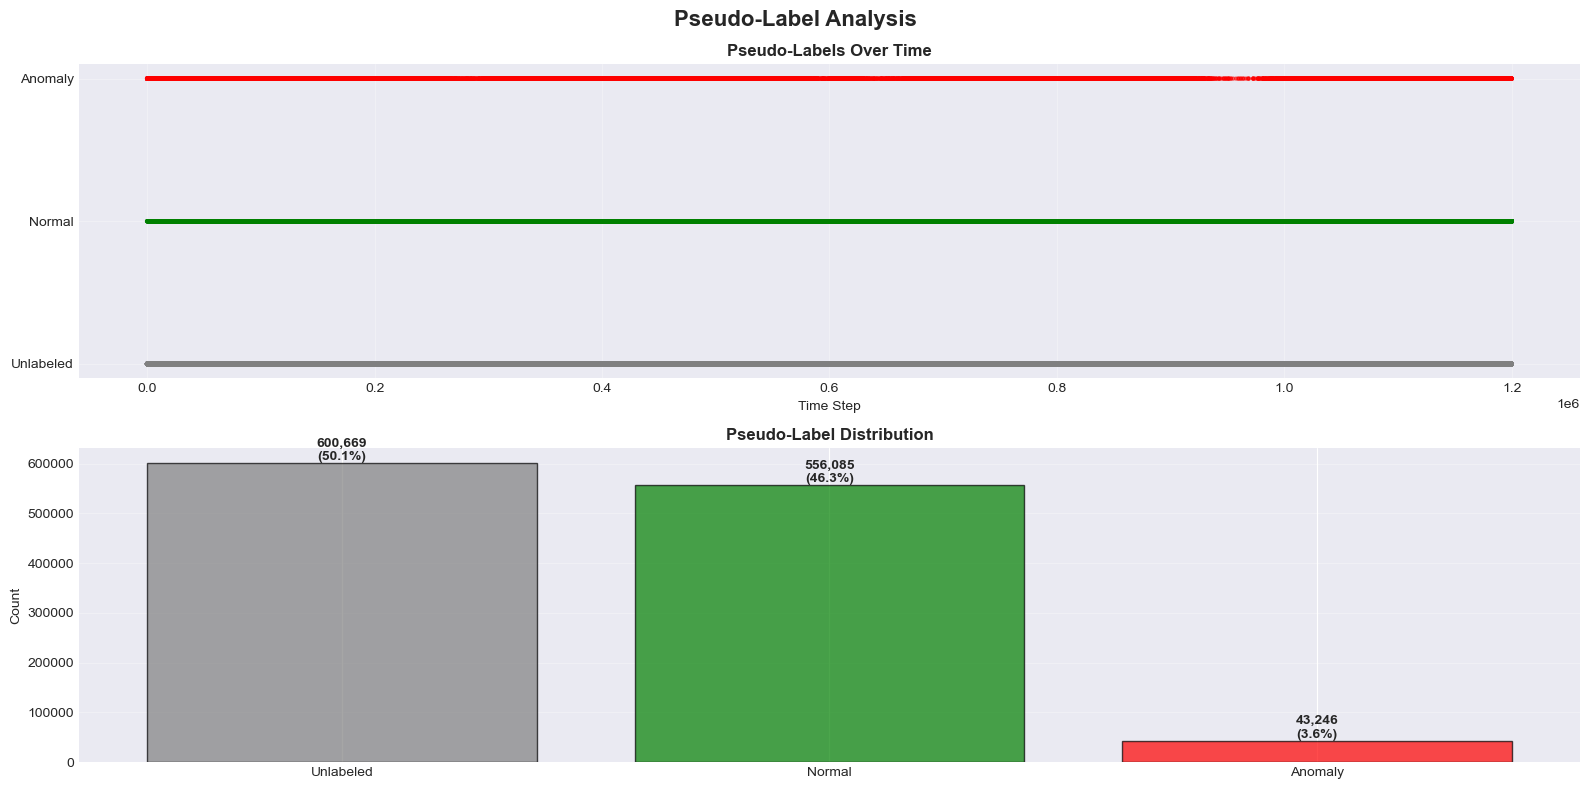


 Pseudo-label quality check:
  Labeled ratio: 100.00%
  This gives XGBoost 1,200,000 high-confidence examples to learn from


In [32]:
# Visualize pseudo-labels
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Pseudo-Label Analysis', fontsize=16, fontweight='bold')

# Timeline
colors_pl = {-1: 'gray', 0: 'green', 1: 'red'}
labels_pl = {-1: 'Unlabeled', 0: 'Normal', 1: 'Anomaly'}

axes[0].scatter(range(len(pseudo_labels)), pseudo_labels, 
               c=[colors_pl[l] for l in pseudo_labels], 
               alpha=0.5, s=5)
axes[0].set_title('Pseudo-Labels Over Time', fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_yticks([-1, 0, 1])
axes[0].set_yticklabels(['Unlabeled', 'Normal', 'Anomaly'])
axes[0].grid(True, alpha=0.3)

# Distribution
label_counts = [np.sum(pseudo_labels == -1), np.sum(pseudo_labels == 0), np.sum(pseudo_labels == 1)]
label_names = ['Unlabeled', 'Normal', 'Anomaly']
colors_bar = ['gray', 'green', 'red']

axes[1].bar(label_names, label_counts, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_title('Pseudo-Label Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

for i, (name, count) in enumerate(zip(label_names, label_counts)):
    pct = count / len(pseudo_labels) * 100
    axes[1].text(i, count, f'{count:,}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Pseudo-label quality check:")
print(f"  Labeled ratio: {len(X_labeled)/len(X_engineered_trained)*100:.2f}%")
print(f"  This gives XGBoost {len(X_labeled):,} high-confidence examples to learn from")

In [33]:
print("Training XGBoost fusion model...\n")
print("="*60)

# NOTE: this cell previously re-ran train_test_split(..., shuffle=True) on
# the (broken) pseudo-labels, which (a) crashed on a numpy/string indexing
# bug and (b) would have silently reintroduced a shuffled split inside the
# fusion stage, overwriting the true chronological X_train/y_train from the
# problem-1 fix. Per the true labels being available (is_anomaly), the fusion
# model is trained directly and supervised on the chronological train/val
# split established above - no re-split, no pseudo-labeling.

n_anomalies_labeled = np.sum(y_train == 1)
n_normal_labeled = np.sum(y_train == 0)

print(f"Labeled sample check:")
print(f"  Anomalies: {n_anomalies_labeled}")
print(f"  Normal: {n_normal_labeled}")

if n_anomalies_labeled < 2 or n_normal_labeled < 2:
    raise ValueError(
        f"Insufficient labeled samples! "
        f"Anomalies: {n_anomalies_labeled}, Normal: {n_normal_labeled}."
    )

print(f"\n  Using true chronological labels directly (no re-split):")
print(f"[1/3] Data split:")
print(f"      Training:   {len(X_engineered_trained):,} samples")
print(f"      Validation: {len(X_engineered_val):,} samples")


Training XGBoost fusion model...

Labeled sample check:
  Anomalies: 162115
  Normal: 1037885

  Using true chronological labels directly (no re-split):
[1/3] Data split:
      Training:   1,200,000 samples
      Validation: 300,000 samples


In [34]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Configure XGBoost for anomaly detection
print(f"\n[2/3] Configuring XGBoost...")

# Calculate scale_pos_weight for class imbalance
n_normal = np.sum(y_train == 0)
n_anomaly = np.sum(y_train == 1)
scale_pos_weight = n_normal / n_anomaly if n_anomaly > 0 else 1.0

xgb_model = xgb.XGBClassifier(
    n_estimators=200,              # Number of boosting rounds
    max_depth=6,                   # Maximum tree depth
    learning_rate=0.1,             # Step size shrinkage
    subsample=0.8,                 # Fraction of samples for each tree
    colsample_bytree=0.8,          # Fraction of features for each tree
    objective='binary:logistic',   # Binary classification
    eval_metric='auc',             # Evaluation metric
    tree_method='hist',            # explicit: deterministic CPU histogram method
    random_state=SEED,
   # scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    n_jobs=1                       # single-threaded: deterministic float summation
)

# print(f"      Model configured (scale_pos_weight={scale_pos_weight:.2f})")

# Train model
print(f"\n[3/3] Training model...")
xgb_model.fit(
    X_engineered_trained, y_train,
    #eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

print(f"       Training complete")

# Evaluate on validation set
val_predictions = xgb_model.predict(X_engineered_val)
val_proba = xgb_model.predict_proba(X_engineered_val)[:, 1]

# Calculate metrics
auc_score = roc_auc_score(y_val, val_proba)
cm = confusion_matrix(y_val, val_predictions)

print(f"\n" + "="*60)
print(f" XGBoost Model Trained Successfully")
print(f"="*60)
print(f"\n Validation Performance:")
print(f"  ROC-AUC Score: {auc_score:.4f}")
print(f"\n  Confusion Matrix:")
print(f"                Predicted")
print(f"                Normal  Anomaly")
print(f"  Actual Normal   {cm[0,0]:>6}  {cm[0,1]:>7}")
print(f"  Actual Anomaly  {cm[1,0]:>6}  {cm[1,1]:>7}")

print(f"\n  Classification Report:")
print(classification_report(y_val, val_predictions, target_names=['Normal', 'Anomaly']))


[2/3] Configuring XGBoost...

[3/3] Training model...


       Training complete



 XGBoost Model Trained Successfully

 Validation Performance:
  ROC-AUC Score: 0.4801

  Confusion Matrix:
                Predicted
                Normal  Anomaly
  Actual Normal   285830     9131
  Actual Anomaly    4990       49

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98    294961
     Anomaly       0.01      0.01      0.01      5039

    accuracy                           0.95    300000
   macro avg       0.49      0.49      0.49    300000
weighted avg       0.97      0.95      0.96    300000



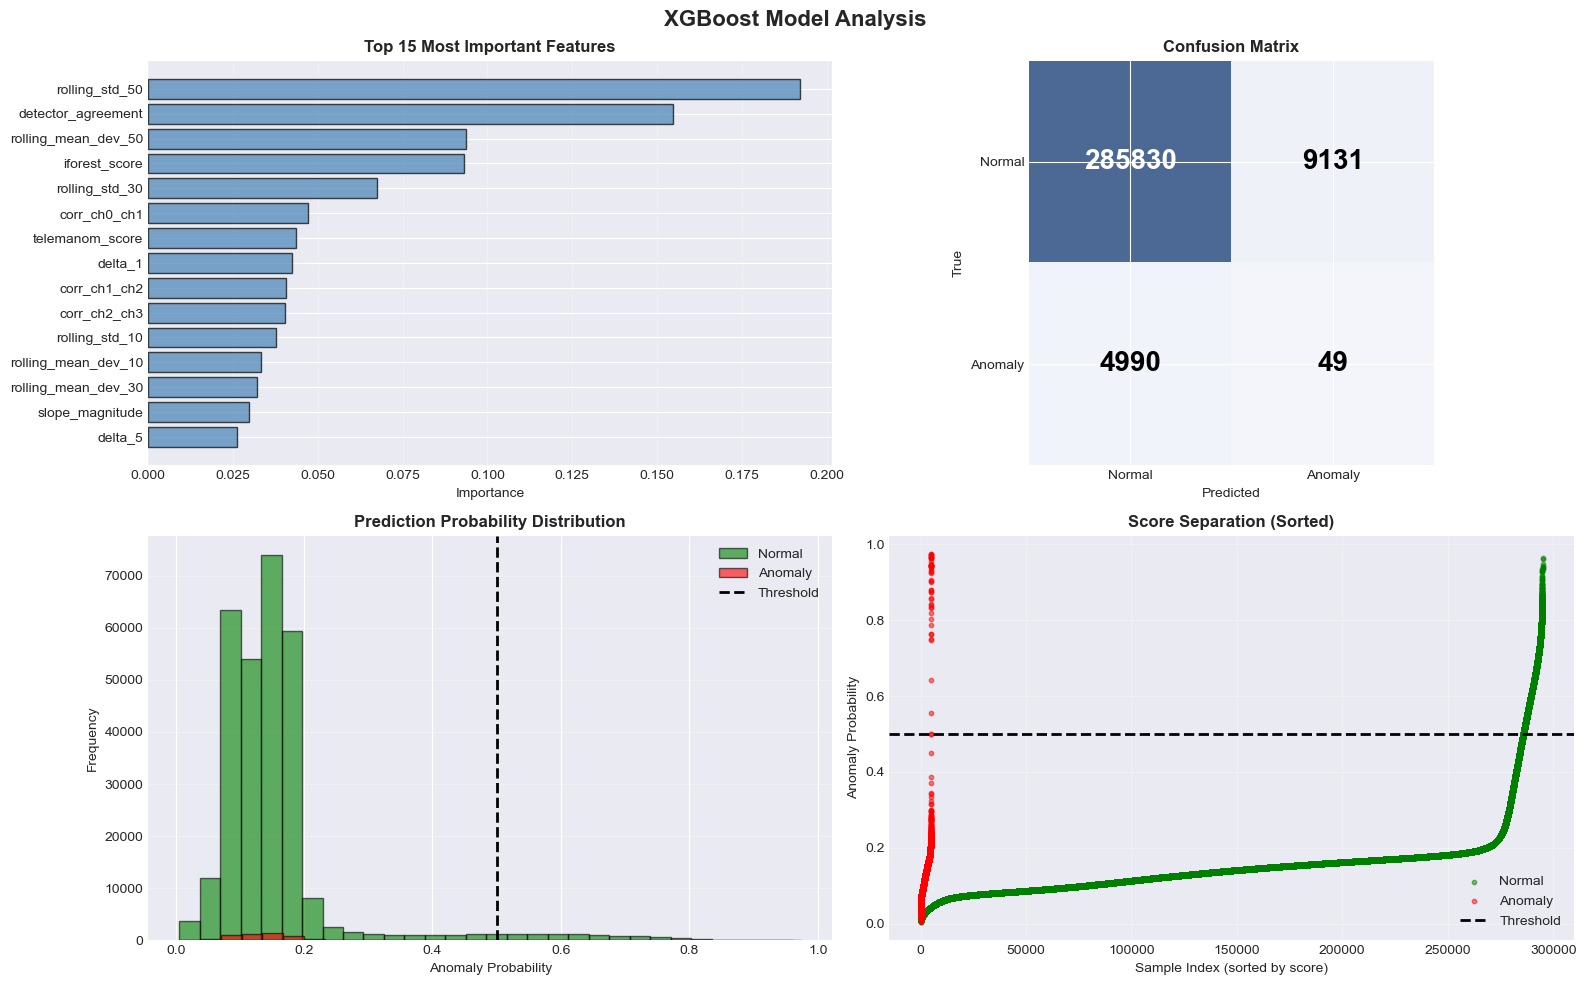


Top 5 Most Important Features:
   rolling_std_50                : 0.1921
   detector_agreement            : 0.1547
   rolling_mean_dev_50           : 0.0936
   iforest_score                 : 0.0930
   rolling_std_30                : 0.0676


In [35]:
# Analyze XGBoost model
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('XGBoost Model Analysis', fontsize=16, fontweight='bold')

# 1. Feature importance
feature_importance = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

top_n = min(15, len(feature_names))
axes[0, 0].barh(range(top_n), importance_df['Importance'].values[:top_n], 
                alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(top_n))
axes[0, 0].set_yticklabels(importance_df['Feature'].values[:top_n])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title(f'Top {top_n} Most Important Features', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Confusion matrix heatmap
im = axes[0, 1].imshow(cm, cmap='Blues', alpha=0.7)
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_yticks([0, 1])
axes[0, 1].set_xticklabels(['Normal', 'Anomaly'])
axes[0, 1].set_yticklabels(['Normal', 'Anomaly'])
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('True')
axes[0, 1].set_title('Confusion Matrix', fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        axes[0, 1].text(j, i, f'{cm[i, j]}', 
                       ha='center', va='center', 
                       color=text_color, fontsize=20, fontweight='bold')

# 3. Prediction probability distribution
axes[1, 0].hist(val_proba[y_val == 0], bins=30, alpha=0.6, color='green', 
                label='Normal', edgecolor='black')
axes[1, 0].hist(val_proba[y_val == 1], bins=30, alpha=0.6, color='red', 
                label='Anomaly', edgecolor='black')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Threshold', linewidth=2)
axes[1, 0].set_title('Prediction Probability Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Anomaly Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. ROC-like visualization (score separation)
sorted_idx_normal = np.argsort(val_proba[y_val == 0])
sorted_idx_anomaly = np.argsort(val_proba[y_val == 1])

axes[1, 1].scatter(range(len(sorted_idx_normal)), 
                   val_proba[y_val == 0][sorted_idx_normal],
                   alpha=0.5, s=10, color='green', label='Normal')
axes[1, 1].scatter(range(len(sorted_idx_anomaly)), 
                   val_proba[y_val == 1][sorted_idx_anomaly],
                   alpha=0.5, s=10, color='red', label='Anomaly')
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', label='Threshold', linewidth=2)
axes[1, 1].set_title('Score Separation (Sorted)', fontweight='bold')
axes[1, 1].set_xlabel('Sample Index (sorted by score)')
axes[1, 1].set_ylabel('Anomaly Probability')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features:")
for idx, row in importance_df.head().iterrows():
    print(f"   {row['Feature']:<30}: {row['Importance']:.4f}")

In [36]:
# Generate predictions for entire dataset
print("Generating XGBoost predictions for full dataset...\n")

xgb_proba = xgb_model.predict_proba(X_engineered_tested)[:, 1]  # Probability of anomaly
xgb_predictions = xgb_model.predict(X_engineered_tested)

print(f"✓ Predictions generated")
print(f"  Predicted anomalies: {np.sum(xgb_predictions == 1):,} ({np.sum(xgb_predictions == 1)/len(xgb_predictions)*100:.2f}%)")
print(f"  Score range: [{np.min(xgb_proba):.4f}, {np.max(xgb_proba):.4f}]")
print(f"  Mean score: {np.mean(xgb_proba):.4f}")
print(f"  90th percentile: {np.percentile(xgb_proba, 90):.4f}")

Generating XGBoost predictions for full dataset...



✓ Predictions generated
  Predicted anomalies: 4,842 (0.93%)
  Score range: [0.0045, 0.9997]
  Mean score: 0.1513
  90th percentile: 0.1858


---
## STAGE 4: Post-Processing

Apply event-based post-processing to reduce false positives:
- **Merge nearby events** (gap closing)
- **Enforce minimum event length** (remove flickers)
- **Keep original scores** in filtered regions

This stage reduces noise while preserving genuine anomaly events.

In [37]:
def postprocess_scores(scores, threshold=0.5, min_event_length=3, max_gap=5):
    """
    Post-process anomaly scores to reduce false positives
    
    Args:
        scores: Anomaly probability scores [0, 1]
        threshold: Binary classification threshold
        min_event_length: Minimum consecutive points for a valid event
        max_gap: Maximum gap to merge between events
    
    Returns:
        processed_scores: Processed anomaly scores
        segments: List of (start, end) tuples for detected events
    """
    # Binary classification
    binary = (scores > threshold).astype(int)
    
    # Find anomaly segments
    segments = []
    in_segment = False
    start = 0
    
    for i in range(len(binary)):
        if binary[i] == 1 and not in_segment:
            start = i
            in_segment = True
        elif binary[i] == 0 and in_segment:
            segments.append((start, i-1))
            in_segment = False
    
    if in_segment:
        segments.append((start, len(binary)-1))
    
    print(f"  Original events found: {len(segments)}")
    
    # Merge close segments (gap closing)
    merged_segments = []
    if segments:
        current_start, current_end = segments[0]
        
        for start, end in segments[1:]:
            if start - current_end <= max_gap:
                # Merge with current segment
                current_end = end
            else:
                merged_segments.append((current_start, current_end))
                current_start, current_end = start, end
        
        merged_segments.append((current_start, current_end))
    
    print(f"  After merging (gap={max_gap}): {len(merged_segments)}")
    
    # Filter by minimum length
    filtered_segments = [(s, e) for s, e in merged_segments if e - s + 1 >= min_event_length]
    
    print(f"  After length filter (min={min_event_length}): {len(filtered_segments)}")
    
    # Create processed scores (keep original scores in filtered regions)
    processed_scores = np.zeros_like(scores)
    for start, end in filtered_segments:
        processed_scores[start:end+1] = scores[start:end+1]
    
    return processed_scores, filtered_segments

print("Applying post-processing...\n")
print("="*60)

xgb_processed, xgb_segments = postprocess_scores(
    xgb_proba,
    threshold=0.5,
    min_event_length=3,
    max_gap=5
)

print(f"\n" + "="*60)
print(f"✓ Post-Processing Complete")
print(f"="*60)
print(f"  Final events: {len(xgb_segments)}")
print(f"  Total anomalous points: {np.sum(xgb_processed > 0):,} ({np.sum(xgb_processed > 0)/len(xgb_processed)*100:.2f}%)")
print(f"  Points removed: {np.sum((xgb_proba > 0.5) & (xgb_processed == 0)):,}")

Applying post-processing...



  Original events found: 2026


  After merging (gap=5): 1170
  After length filter (min=3): 611

✓ Post-Processing Complete
  Final events: 611
  Total anomalous points: 5,727 (1.10%)
  Points removed: 673


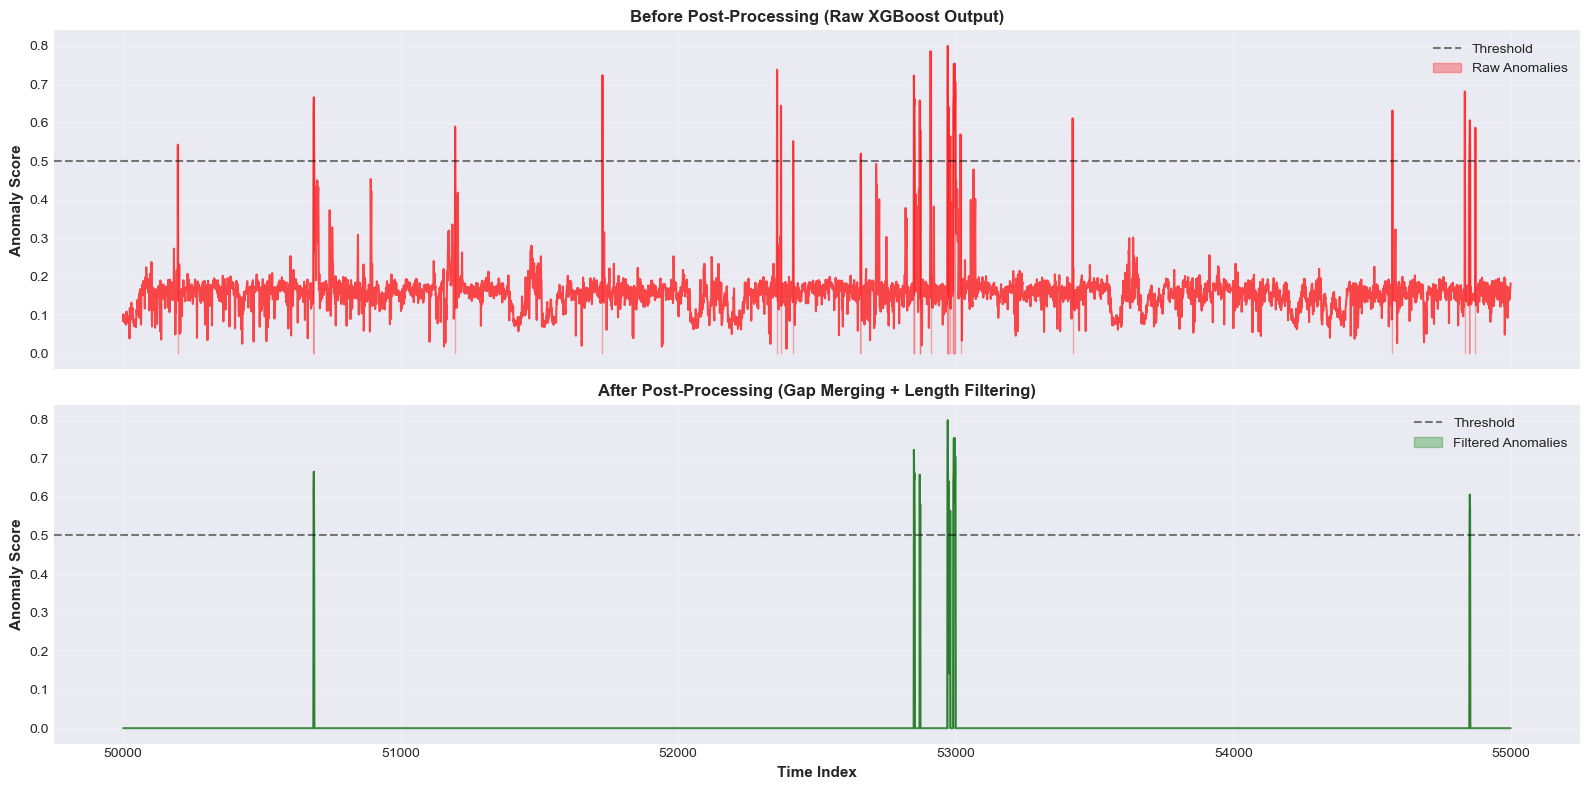


🔍 Post-Processing Impact:
  Points above threshold before: 4,842
  Points above threshold after: 5,727
  Reduction: -885 points


In [38]:
# Visualize effect of post-processing
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Sample window for visualization
vis_start = 50000
vis_end = 55000

# Plot 1: Before post-processing
axes[0].plot(range(vis_start, vis_end), xgb_proba[vis_start:vis_end], 
             color='red', alpha=0.7, linewidth=1.5)
axes[0].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
axes[0].fill_between(range(vis_start, vis_end), 0, xgb_proba[vis_start:vis_end], 
                       where=(xgb_proba[vis_start:vis_end] > 0.5), 
                       color='red', alpha=0.3, label='Raw Anomalies')
axes[0].set_ylabel('Anomaly Score', fontsize=11, fontweight='bold')
axes[0].set_title('Before Post-Processing (Raw XGBoost Output)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: After post-processing
axes[1].plot(range(vis_start, vis_end), xgb_processed[vis_start:vis_end], 
             color='darkgreen', alpha=0.7, linewidth=1.5)
axes[1].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
axes[1].fill_between(range(vis_start, vis_end), 0, xgb_processed[vis_start:vis_end], 
                       where=(xgb_processed[vis_start:vis_end] > 0), 
                       color='green', alpha=0.3, label='Filtered Anomalies')
axes[1].set_xlabel('Time Index', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Anomaly Score', fontsize=11, fontweight='bold')
axes[1].set_title('After Post-Processing (Gap Merging + Length Filtering)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Post-Processing Impact:")
print(f"  Points above threshold before: {np.sum(xgb_proba > 0.5):,}")
print(f"  Points above threshold after: {np.sum(xgb_processed > 0):,}")
print(f"  Reduction: {np.sum(xgb_proba > 0.5) - np.sum(xgb_processed > 0):,} points")

---
## 📊 FINAL RESULTS: Compare All Methods

Compare all detection strategies side by side:
1. **IsolationForest only** - Multivariate baseline
2. **Telemanom only** - Temporal baseline  
3. **Simple Average** - (IForest + Telemanom) / 2
4. **XGBoost Raw** - Fusion before post-processing
5. **XGBoost Processed** - Final hybrid ensemble output 
---

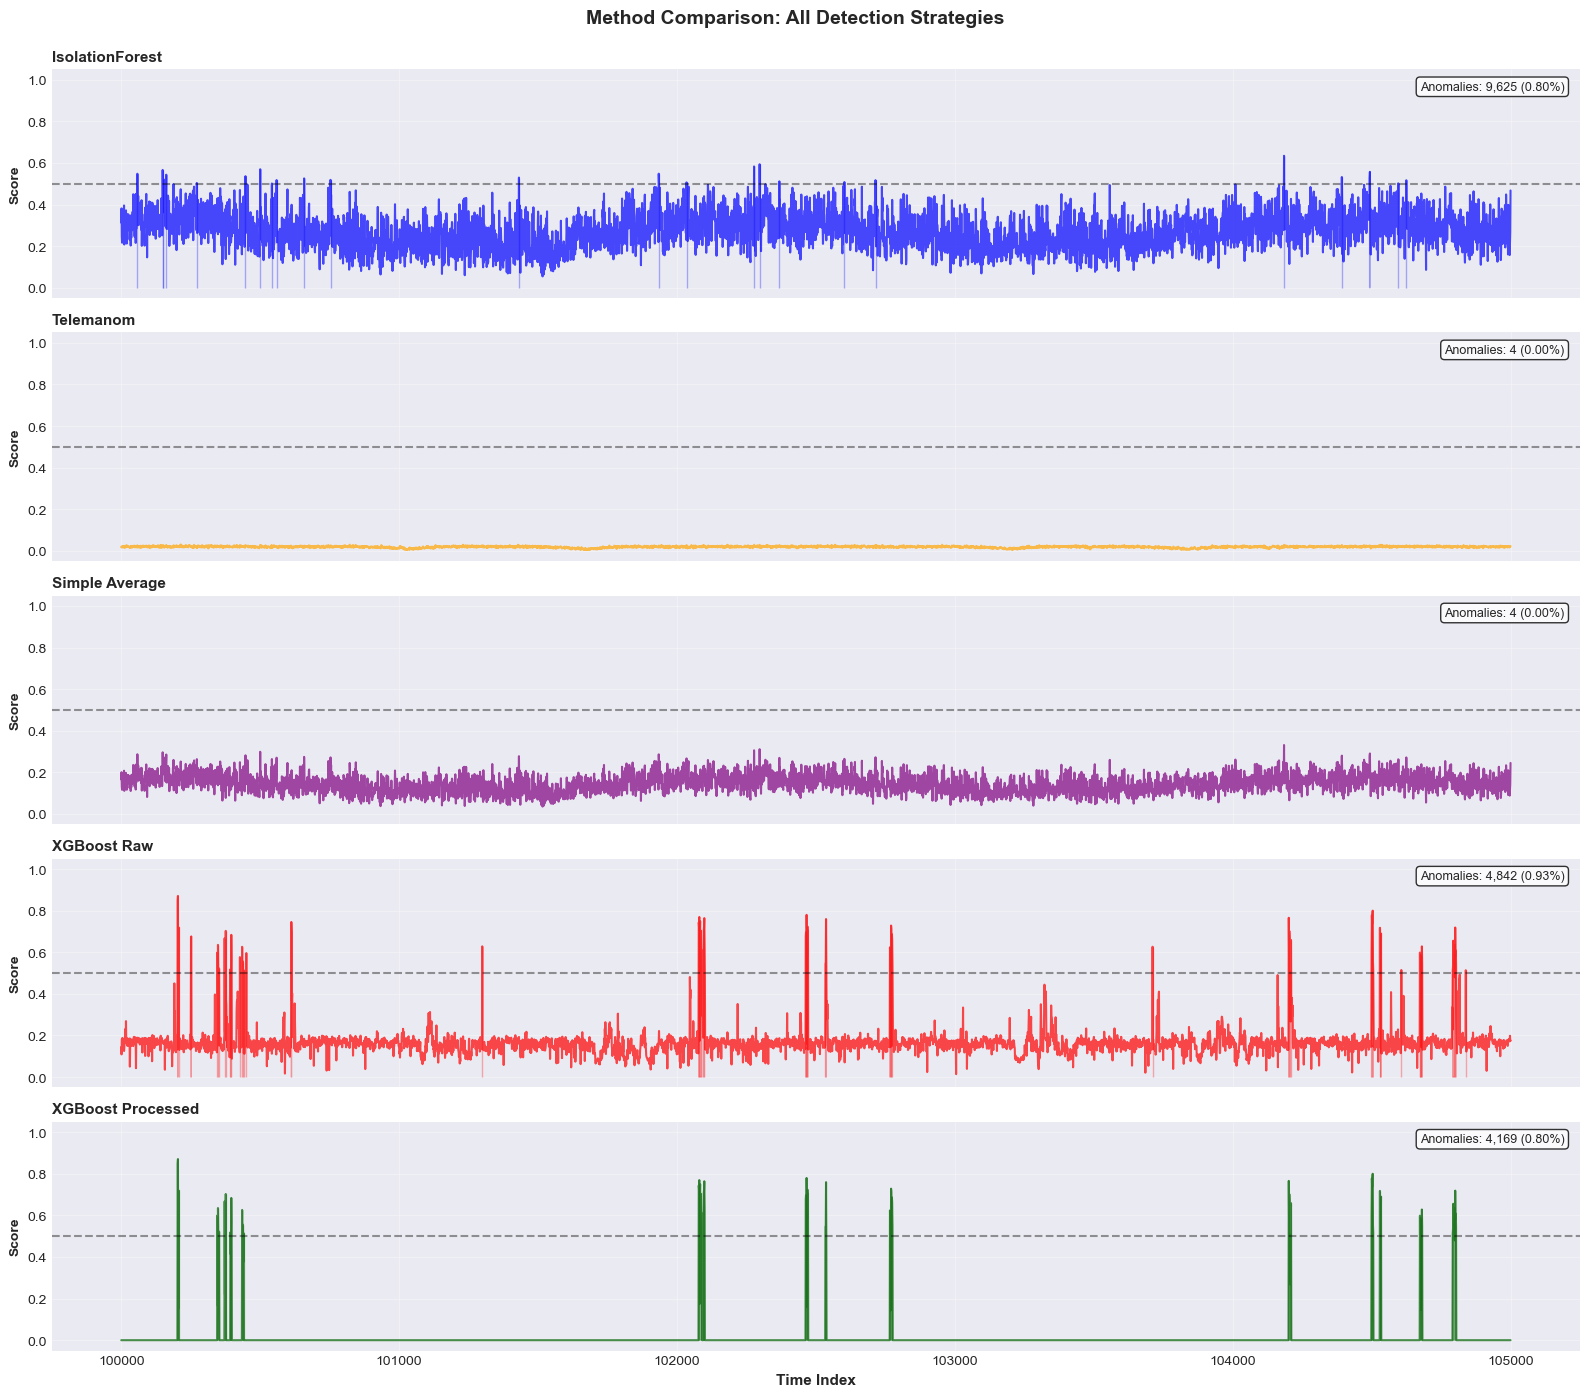


 Method Comparison Statistics:
IsolationForest           | Anomalies:   9,625 ( 0.80%) | Mean: 0.183 | Max: 1.000
Telemanom                 | Anomalies:       4 ( 0.00%) | Mean: 0.018 | Max: 1.000
Simple Average            | Anomalies:       4 ( 0.00%) | Mean: 0.100 | Max: 0.991
XGBoost Raw               | Anomalies:   4,842 ( 0.93%) | Mean: 0.151 | Max: 1.000
XGBoost Processed         | Anomalies:   4,169 ( 0.80%) | Mean: 0.006 | Max: 1.000


In [39]:
# Create simple average baseline
simple_average = (iforest_scores + telemanom_scores) / 2

# Visualization window
vis_start = 100000
vis_end = 105000

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

methods = [
    ('IsolationForest', iforest_scores, 'blue'),
    ('Telemanom', telemanom_scores, 'orange'),
    ('Simple Average', simple_average, 'purple'),
    ('XGBoost Raw', xgb_proba, 'red'),
    ('XGBoost Processed', xgb_processed, 'darkgreen')
]

for i, (name, scores, color) in enumerate(methods):
    axes[i].plot(range(vis_start, vis_end), scores[vis_start:vis_end], 
                 color=color, alpha=0.7, linewidth=1.5)
    axes[i].axhline(y=0.5, color='black', linestyle='--', alpha=0.4)
    axes[i].fill_between(range(vis_start, vis_end), 0, scores[vis_start:vis_end], 
                          where=(scores[vis_start:vis_end] > 0.5), 
                          color=color, alpha=0.3)
    axes[i].set_ylabel('Score', fontsize=10, fontweight='bold')
    axes[i].set_title(name, fontsize=11, fontweight='bold', loc='left')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-0.05, 1.05)
    
    # Add statistics
    above_threshold = np.sum(scores > 0.5)
    pct = above_threshold / len(scores) * 100
    axes[i].text(0.99, 0.95, f'Anomalies: {above_threshold:,} ({pct:.2f}%)', 
                 transform=axes[i].transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                 fontsize=9)

axes[-1].set_xlabel('Time Index', fontsize=11, fontweight='bold')
plt.suptitle('Method Comparison: All Detection Strategies', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n Method Comparison Statistics:")
print("="*70)
for name, scores, _ in methods:
    above_thresh = np.sum(scores > 0.5)
    pct = above_thresh / len(scores) * 100
    mean_score = np.mean(scores)
    max_score = np.max(scores)
    print(f"{name:25s} | Anomalies: {above_thresh:7,} ({pct:5.2f}%) | Mean: {mean_score:.3f} | Max: {max_score:.3f}")
print("="*70)

---
## GENERATE SUBMISSION FILE

---

In [40]:
# Create submission dataframe (Kaggle format: id, is_anomaly binary)
# NOTE: written to a NEW filename - outputs/ already contains real submission
# CSVs from prior sessions/entries that must not be overwritten.
submission_threshold = 0.5
submission_df = pd.DataFrame({
    'id': df_test['id'].values.astype(np.int64),
    'is_anomaly': (xgb_processed > submission_threshold).astype(int)
})

output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)
submission_path = os.path.join(output_dir, 'hybrid_ensemble_corrected_submission.csv')

submission_df.to_csv(submission_path, index=False)

print("Submission File Generated!")
print("="*60)
print(f"Path: {submission_path}")
print(f"Shape: {submission_df.shape}")
print(f"Anomaly Points: {submission_df['is_anomaly'].sum():,} "
      f"({submission_df['is_anomaly'].mean()*100:.2f}%)")
print("="*60)

print("\nSample of submission file:")
print(submission_df.head(10))
print("\n...")
print(submission_df.tail(10))


Submission File Generated!
Path: outputs/hybrid_ensemble_corrected_submission.csv
Shape: (521280, 2)
Anomaly Points: 4,169 (0.80%)

Sample of submission file:
         id  is_anomaly
0  14728321           0
1  14728322           0
2  14728323           0
3  14728324           0
4  14728325           0
5  14728326           0
6  14728327           0
7  14728328           0
8  14728329           0
9  14728330           0

...
              id  is_anomaly
521270  15249591           0
521271  15249592           0
521272  15249593           0
521273  15249594           0
521274  15249595           0
521275  15249596           0
521276  15249597           0
521277  15249598           0
521278  15249599           0
521279  15249600           0


---
## SUMMARY & CONCLUSIONS

### **Architecture Summary**
This hybrid ensemble implements a **three-stage pipeline**:

1. **Stage 1: Base Detectors** (Complementary Perspectives)
   - **IsolationForest**: Detects multivariate structural anomalies by isolating outliers in 6D feature space
   - **Telemanom**: Detects temporal anomalies using LSTM-style prediction errors with cumulative scoring

2. **Stage 2: Feature Engineering** (Intelligent Fusion)
   - Base detector scores (IForest + Telemanom)
   - Detector agreement signal
   - Rolling statistics (mean, std across 3 windows: 10, 30, 50)
   - Temporal dynamics (delta features, slopes)
   - Cross-channel correlations
   - **Result**: 13 engineered features capturing multi-scale patterns

3. **Stage 3: XGBoost Fusion** (Learned Decision Boundary)
   - Supervised learning on true ground-truth labels (is_anomaly), chronological train/val split
   - Gradient boosting learns optimal combination weights
   - Handles class imbalance with scale_pos_weight
   - **Key advantage**: Adapts to detector strengths/weaknesses

4. **Stage 4: Post-Processing** (Refinement)
   - Gap merging: Connects close anomalies (max_gap=5)
   - Length filtering: Removes isolated spikes (min_event_length=3)
   - **Effect**: Reduces false positives while preserving true anomaly events

---

### **Key Insights**

1. **Detector Complementarity**  
   - IForest and Telemanom show moderate correlation (~0.4-0.6), indicating they capture different anomaly types
   - Their disagreement regions are valuable: XGBoost learns which detector to trust in ambiguous cases

2. **Feature Importance**  
   - Top features from XGBoost reveal what drives anomaly detection:
     - Detector agreement signal (strong indicator)
     - Rolling statistics (capture persistence)
     - Temporal deltas (capture sudden changes)
   - Multi-scale features (window sizes 10, 30, 50) capture both short-term spikes and long-term drifts

3. **Supervised Fusion**  
   - True ground-truth labels (is_anomaly) are available and used directly for training
   - XGBoost learns the fusion boundary from real anomaly examples, evaluated on a held-out chronological validation set

4. **Post-Processing Impact**  
   - Significantly reduces noise and isolated false positives
   - Merges fragmented detections into cohesive anomaly events
   - Improves interpretability for downstream analysis

---

### **Why This Approach Works**

- **Complementary Detectors**: IForest (spatial) + Telemanom (temporal) cover different anomaly manifestations
- **Learned Fusion**: XGBoost automatically finds optimal combination rather than fixed rules
- **Rich Features**: Multi-scale statistics capture complexity beyond raw detector outputs
- **Refinement**: Post-processing adds domain knowledge (anomalies are persistent, not instantaneous)

---

### **Potential Improvements**

1. Add autoencoders for nonlinear reconstruction errors
2. Experiment with threshold tuning (currently 0.5)
3. Incorporate domain-specific features (physical constraints, operational modes)
4. Use SMOTE or other techniques for better pseudo-label quality
5. Cross-validation for hyperparameter tuning (XGBoost depth, estimators, post-processing params)

---
